# Import modules and set float format

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from scipy.stats import mannwhitneyu, wilcoxon, linregress
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

pd.set_option('float_format', '{:f}'.format)
sns.set_style('white')

# Import data
* Fixed column order

In [2]:
raw = pd.read_csv('/Users/jpdemuth/5Species/Data/combined_data_5_species.csv')  ## edit path to data
data=raw[['OrthoID', 'seq_id', 'sample', 'gender', 'species', 'chrom_num', 'chrom_name', 'Current_TMM']]
data.groupby('species').describe().transpose()

species                 G_corn       T_brev       T_cast       T_conf  \
Current_TMM count 66688.000000 71908.000000 61536.000000 67916.000000   
            mean     28.359864    41.578613    48.618394    34.455476   
            std     240.010558   598.835418   316.412056   312.315008   
            min       0.000000     0.000000     0.000000     0.000000   
            25%       0.244667     0.241882     0.602677     0.236868   
            50%       3.207240     2.504949     8.846313     3.759857   
            75%      16.271572    16.780583    29.159560    19.267721   
            max   20416.027540 57926.771350 28917.386230 31306.320040   

species                 T_frem  
Current_TMM count 74156.000000  
            mean     36.601874  
            std     307.786369  
            min       0.000000  
            25%       0.187067  
            50%       2.969612  
            75%      19.301871  
            max   40378.115650

# Filter - single copy orthologs

In [3]:
# identify candidate single-copy orthogroups from the imported table

og_summary = (
    data.groupby("OrthoID")
        .agg(
            n_rows=("OrthoID", "size"),
            n_species=("species", "nunique"),
            n_samples=("sample", "nunique"),
            n_seq_ids=("seq_id", "nunique")
        )
)

# filter to single-copy orthogroups
single_copy_ogs = og_summary[
    (og_summary["n_species"] == 5) &
    (og_summary["n_seq_ids"] == og_summary["n_species"])
].index

print(f"Single-copy orthogroups found: {len(single_copy_ogs)}")

# create single copy dataframe
sc_ortho_df = data[data["OrthoID"].isin(single_copy_ogs)].copy()

# show total number
sc_ortho_df.groupby("species")["OrthoID"].nunique()

Single-copy orthogroups found: 4082


species
G_corn    4082
T_brev    4082
T_cast    4082
T_conf    4082
T_frem    4082
Name: OrthoID, dtype: int64

In [4]:
#Descriptive statistics
sc_ortho_df.groupby('species').describe().transpose()

species                 G_corn       T_brev       T_cast       T_conf  \
Current_TMM count 16328.000000 16328.000000 16328.000000 16328.000000   
            mean     14.934902    44.829916    33.835756    18.383993   
            std      18.302623   711.132958   267.621513    30.718071   
            min       0.000000     0.000000     0.000000     0.000000   
            25%       3.540836     3.548874     6.482028     3.863618   
            50%       9.729320    10.279982    15.344836    11.361407   
            75%      19.365459    22.007293    29.462464    22.754177   
            max     292.152809 43195.014540 28917.386230  1591.126172   

species                 T_frem  
Current_TMM count 16328.000000  
            mean     37.506513  
            std     286.115071  
            min       0.000000  
            25%       5.120969  
            50%      12.803552  
            75%      25.379686  
            max   18103.850830

# Histogram: Unscaled TMM values

<Figure size 400x200 with 0 Axes>

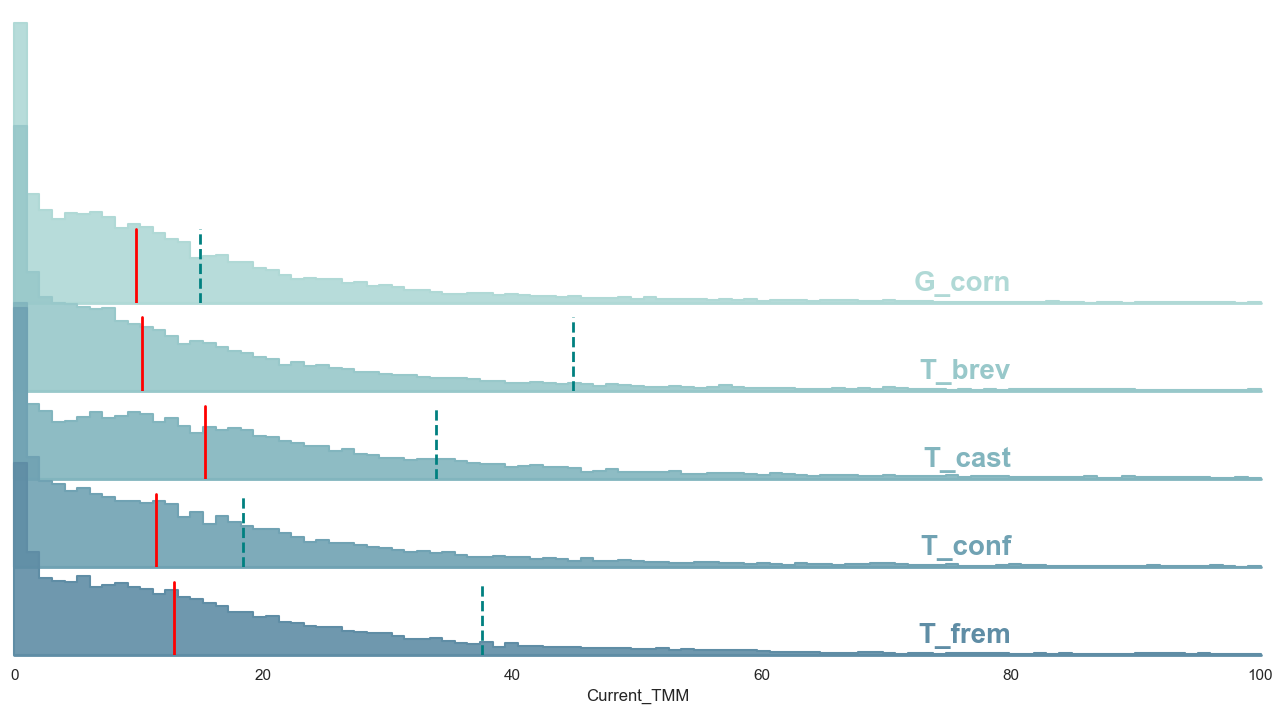

In [5]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.figure(figsize=(4,2))

# Initialize the FacetGrid object (controls for faded color and size of subplots)
pal = sns.cubehelix_palette(10, rot=-.25, light=.8)
g = sns.FacetGrid(sc_ortho_df, row="species", hue="species", aspect=9, height=1.5, palette=pal)

# Draw the histograms (controls for style of bars) 
g.map(sns.histplot, "Current_TMM", clip_on=False, fill=True, alpha=.9, lw=1.5, bins=np.linspace(0,100,100), element="step");

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False);

# Label each subplot (control position on axes(h,v))
def label(x, color, label):
    ax = plt.gca()
    ax.text(.8, .11, label, fontweight="bold", fontsize="20", color=color, ha="right", va="top", transform=ax.transAxes)


g.map(label, "Current_TMM")

# Set the amount of subplot overlap
g.figure.subplots_adjust(hspace=-.7);

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(xlim = (0,100))
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Draw median line on each distribution (note: ymax + hspace above = 1 to draw between axes)
median_position = sc_ortho_df.groupby(['species'])['Current_TMM'].median()
for ax, median_line in zip(g.axes.flat, median_position):
    ax.axvline(x=median_line, ymax = .25, color='red', linestyle='-', lw = 2);
    
mean_position = sc_ortho_df.groupby(['species'])['Current_TMM'].mean()
for ax, mean_line in zip(g.axes.flat, mean_position):
    ax.axvline(x=mean_line, ymax = .25, color='teal', linestyle='--', lw = 2);

# Scale Data - make medians equivalent across species
* https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html

In [6]:
cols=['Current_TMM']

scaled_df = sc_ortho_df.copy()

scaled_df['robust_TMM'] = (scaled_df.groupby('species')['Current_TMM'].transform(lambda x: RobustScaler().fit_transform(x.values.reshape(-1,1)).flatten()))

shift = abs(scaled_df['robust_TMM'].min()) + 0.01
scaled_df['positive_robust_TMM'] = scaled_df['robust_TMM'] + shift

scaled_df.drop(columns=['robust_TMM'], inplace=True)

In [7]:
### OPTIONAL WRITE scaled_df with replicates checkpoint
scaled_df.to_csv('scaled_df.csv', index=False)
scaled_df.groupby('species').describe().transpose()

species                         G_corn       T_brev       T_cast       T_conf  \
Current_TMM         count 16328.000000 16328.000000 16328.000000 16328.000000   
                    mean     14.934902    44.829916    33.835756    18.383993   
                    std      18.302623   711.132958   267.621513    30.718071   
                    min       0.000000     0.000000     0.000000     0.000000   
                    25%       3.540836     3.548874     6.482028     3.863618   
                    50%       9.729320    10.279982    15.344836    11.361407   
                    75%      19.365459    22.007293    29.462464    22.754177   
                    max     292.152809 43195.014540 28917.386230  1591.126172   
positive_robust_TMM count 16328.000000 16328.000000 16328.000000 16328.000000   
                    mean      1.006689     2.549506     1.482372     1.049486   
                    std       1.156591    38.526213    11.645624     1.626107   
                    min       0.062913     0.120808     0.010000     0.076302   
                    25%       0.286668     0.313071     0.292067     0.280828   
                    50%       0.677735     0.677735     0.677735     0.677735   
                    75%       1.286668     1.313071     1.292067     1.280828   
                    max      18.524826  2340.246231  1258.358067    84.304948   

species                         T_frem  
Current_TMM         count 16328.000000  
                    mean     37.506513  
                    std     286.115071  
                    min       0.000000  
                    25%       5.120969  
                    50%      12.803552  
                    75%      25.379686  
                    max   18103.850830  
positive_robust_TMM count 16328.000000  
                    mean      1.897109  
                    std      14.123060  
                    min       0.045733  
                    25%       0.298511  
                    50%       0.677735  
                    75%       1.298511  
                    max     893.678393

# Histogram: Scaled TMM

<Figure size 400x200 with 0 Axes>

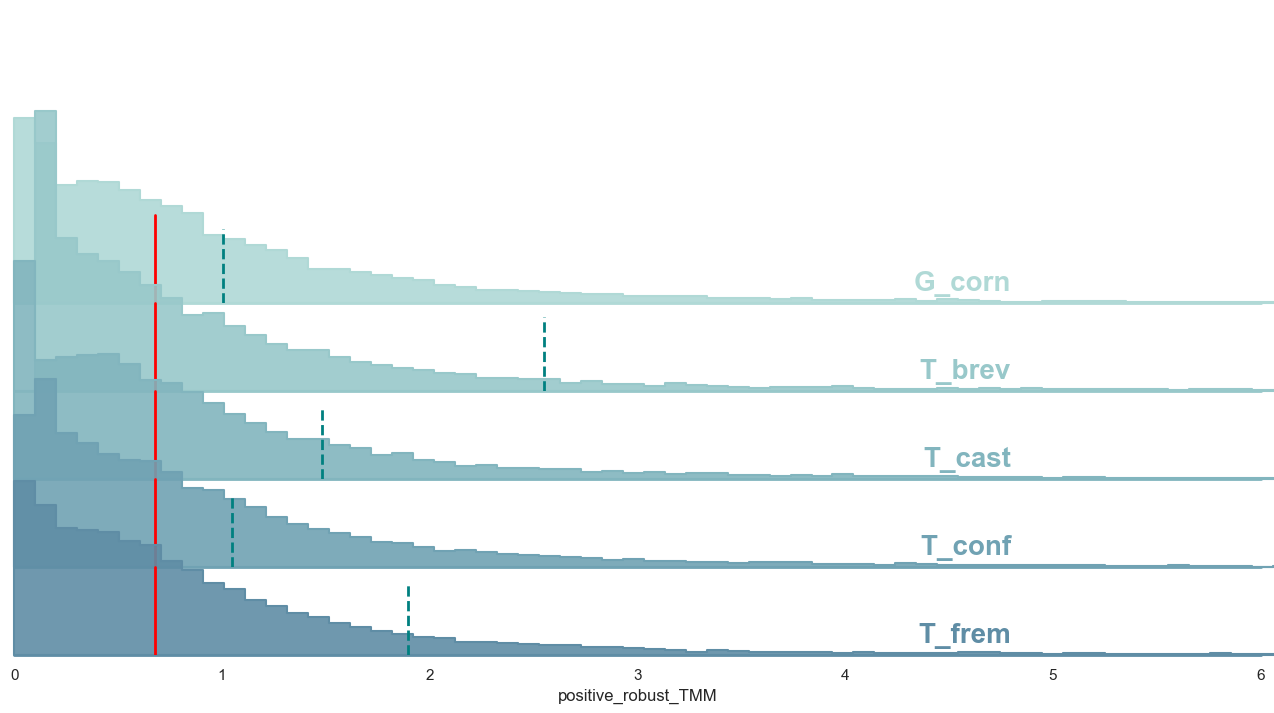

In [8]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.figure(figsize=(4,2))

# Initialize the FacetGrid object (controls for faded color and size of subplots)
pal = sns.cubehelix_palette(10, rot=-.25, light=.8)
g = sns.FacetGrid(scaled_df, row="species", hue="species", aspect=9, height=1.5, palette=pal)

# Draw the histograms (controls for style of bars) 
g.map(sns.histplot, "positive_robust_TMM", clip_on=False, fill=True, alpha=.9, lw=1.5, bins=np.linspace(0,10,100), element="step")


# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False);

# Label each subplot (control position on axes(h,v))
def label(x, color, label):
    ax = plt.gca()
    ax.text(.8, .11, label, fontweight="bold", fontsize="20", color=color, ha="right", va="top", transform=ax.transAxes)


g.map(label, "positive_robust_TMM")

# Set the amount of subplot overlap
g.figure.subplots_adjust(hspace=-.7);

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(xlim = (0,6))
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Draw median line on each distribution (note: ymax + hspace above = 1 to draw between axes)
median_position = scaled_df.groupby(['species'])['positive_robust_TMM'].median()
for ax, median_line in zip(g.axes.flat, median_position):
    ax.axvline(x=median_line, ymax = .3, color='red', linestyle='-', lw = 2);
    
mean_position = scaled_df.groupby(['species'])['positive_robust_TMM'].mean()
for ax, mean_line in zip(g.axes.flat, mean_position):
    ax.axvline(x=mean_line, ymax = .25, color='teal', linestyle='--', lw = 2);

# Lineplot: Median Expression Across Chromosomes (unscaled & scaled)

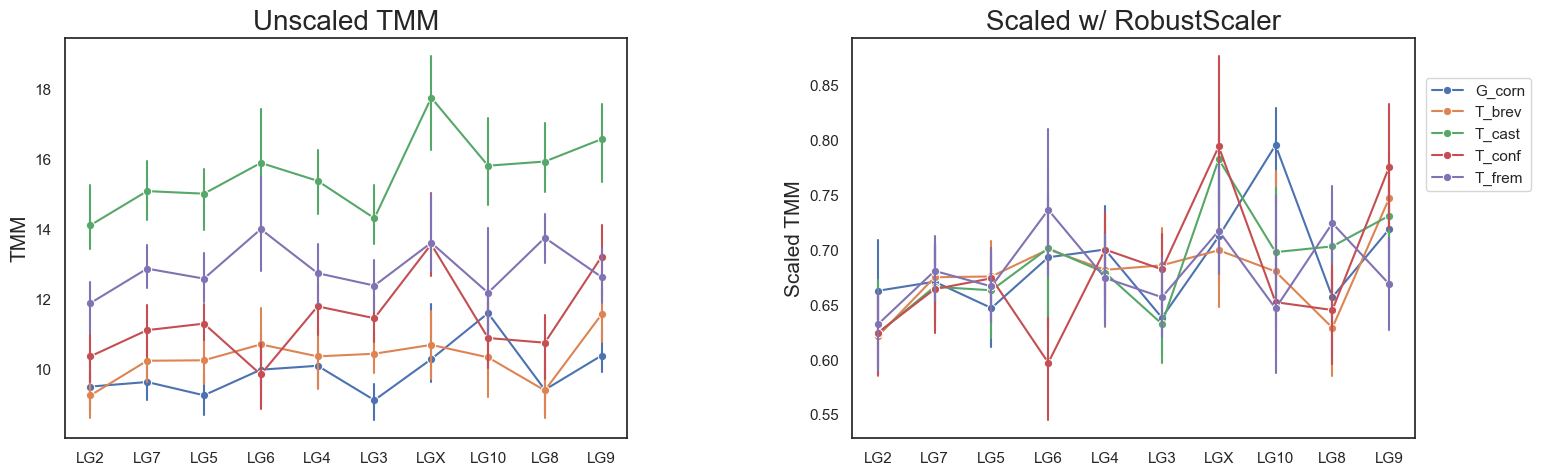

In [9]:
sns.set_style('white')
fig3, axes = plt.subplots(1, 2, figsize=(15,5))
plt.subplots_adjust(left=0.1,bottom=0.1,right=1,top=0.9,wspace=0.4,hspace=0.4)

sns.lineplot(ax=axes[0],data=scaled_df, x='chrom_num', y='Current_TMM', hue = 'species', estimator = np.median, errorbar=('ci', 95), err_style='bars', marker='o', color='blue')
axes[0].set_title ('Unscaled TMM', fontsize=20)
axes[0].set_ylabel('TMM',          fontsize=15)
axes[0].set_xlabel(None)
axes[0].legend_.remove()

sns.lineplot(ax=axes[1],data=scaled_df, x='chrom_num', y='positive_robust_TMM', hue = 'species', estimator = np.median, errorbar=('ci', 95), err_style='bars', marker='o', color='blue')
axes[1].set_title('Scaled w/ RobustScaler', fontsize=20)
axes[1].set_ylabel('Scaled TMM'  , fontsize=15)
axes[1].set_xlabel(None)
axes[1].legend(scaled_df['species'].unique(),bbox_to_anchor=(1.02, .9), loc='upper left', borderaxespad=0);

# Combine replicates and separate sexes

In [10]:
scaled_mean_df = pd.read_csv('scaled_df.csv')
scaled_mean_df = scaled_mean_df.groupby(['OrthoID', 'species', 'gender', 'chrom_num','chrom_name']).agg({'Current_TMM':['mean','sem'],'positive_robust_TMM':['mean','sem'],}).reset_index()
scaled_mean_df.columns = ["_".join(col_name).rstrip('_') for col_name in scaled_mean_df.columns.to_flat_index()] 

### OPTIONAL WRITE scaled_df after combining replicates checkpoint
scaled_mean_df.to_csv('scaled_mean_df.csv', index=False)
#display(scaled_mean_df.groupby('species')[['Current_TMM_mean','positive_robust_TMM_mean']].describe().transpose())

## Split Male and Female Data
Male_df   = scaled_mean_df.loc[(scaled_mean_df['gender']=='Male')]
Female_df = scaled_mean_df.loc[(scaled_mean_df['gender']=='Female')]

##Display
display(Male_df.groupby('species')[['Current_TMM_mean','positive_robust_TMM_mean']].describe().transpose())
display(Female_df.groupby('species')[['Current_TMM_mean','positive_robust_TMM_mean']].describe().transpose())

species                             G_corn       T_brev      T_cast  \
Current_TMM_mean         count 4082.000000  4082.000000 4082.000000   
                         mean    14.960115    47.402995   32.627598   
                         std     17.605109   723.734199  153.851755   
                         min      0.000000     0.000000    0.000000   
                         25%      3.749762     3.685473    6.308700   
                         50%     10.006865    10.554866   14.927624   
                         75%     19.814007    22.059675   28.580162   
                         max    288.988142 33661.707170 6896.306470   
positive_robust_TMM_mean count 4082.000000  4082.000000 4082.000000   
                         mean     1.008283     2.688905    1.429799   
                         std      1.112514    39.208895    6.694902   
                         min      0.062913     0.120808    0.010000   
                         25%      0.299871     0.320472    0.284525   
                         50%      0.695274     0.692627    0.659580   
                         75%      1.315013     1.315909    1.253674   
                         max     18.324843  1823.771467  300.104685   

species                             T_conf      T_frem  
Current_TMM_mean         count 4082.000000 4082.000000  
                         mean    18.090143   33.037585  
                         std     28.433923  180.666293  
                         min      0.000000    0.000000  
                         25%      4.065720    5.548010  
                         50%     11.679657   13.537254  
                         75%     22.571559   26.394822  
                         max   1059.268545 5759.175109  
positive_robust_TMM_mean count 4082.000000 4082.000000  
                         mean     1.033931    1.676516  
                         std      1.505192    8.917954  
                         min      0.076302    0.045733  
                         25%      0.291527    0.319591  
                         50%      0.694582    0.713951  
                         75%      1.271161    1.348620  
                         max     56.150268  284.327073

species                             G_corn       T_brev       T_cast  \
Current_TMM_mean         count 4082.000000  4082.000000  4082.000000   
                         mean    14.909689    42.256836    35.043914   
                         std     18.641773   657.343613   278.652145   
                         min      0.000000     0.000000     0.000000   
                         25%      3.539761     3.644903     7.416690   
                         50%      9.583623    10.273430    16.400223   
                         75%     18.982879    21.438153    30.848342   
                         max    259.921909 33436.918155 16169.552662   
positive_robust_TMM_mean count 4082.000000  4082.000000  4082.000000   
                         mean     1.005096     2.410107     1.534946   
                         std      1.178023    35.612131    12.125625   
                         min      0.062913     0.120808     0.010000   
                         25%      0.286600     0.318274     0.332739   
                         50%      0.668528     0.677380     0.723660   
                         75%      1.262492     1.282238     1.352374   
                         max     16.488070  1811.593337   703.632560   

species                             T_conf       T_frem  
Current_TMM_mean         count 4082.000000  4082.000000  
                         mean    18.677843    41.975442  
                         std     32.217824   335.282269  
                         min      0.000000     0.000000  
                         25%      3.833299     4.819843  
                         50%     10.970735    12.211136  
                         75%     22.709803    24.634292  
                         max   1296.551701 10425.943629  
positive_robust_TMM_mean count 4082.000000  4082.000000  
                         mean     1.065041     2.117702  
                         std      1.705499    16.550025  
                         min      0.076302     0.045733  
                         25%      0.279223     0.283647  
                         50%      0.657054     0.648492  
                         75%      1.278479     1.261718  
                         max     68.711208   514.685619

# Export for Ancestral Character Estimation (ACE) in R
- Pivot data 
- Remove sex specific genes from sex where they are not expressed

In [11]:
## Pivot Data to phytools format (Orthogroups in columns)
M_mean_df = Male_df.pivot_table  (index='species',columns='OrthoID', values = 'Current_TMM_mean').reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()
M_sem_df  = Male_df.pivot_table  (index='species',columns='OrthoID', values = 'Current_TMM_mean') .reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()
M_Robust_mean_df = Male_df.pivot_table  (index='species',columns='OrthoID', values = 'positive_robust_TMM_mean').reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()
M_Robust_sem_df  = Male_df.pivot_table  (index='species',columns='OrthoID', values = 'positive_robust_TMM_sem') .reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()

F_mean_df = Female_df.pivot_table(index='species',columns='OrthoID', values = 'Current_TMM_mean').reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()
F_sem_df  = Female_df.pivot_table(index='species',columns='OrthoID', values = 'Current_TMM_mean') .reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()
F_Robust_mean_df = Female_df.pivot_table(index='species',columns='OrthoID', values = 'positive_robust_TMM_mean').reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()
F_Robust_sem_df  = Female_df.pivot_table(index='species',columns='OrthoID', values = 'positive_robust_TMM_sem') .reindex(['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']).reset_index()


## Filter out sex-specific genes (i.e. TMM = 0)
M_zeros_list = (M_mean_df.loc[:, (M_mean_df==0).any()]).columns
F_zeros_list = (F_mean_df.loc[:, (F_mean_df==0).any()]).columns

M_mean_filtered_df = M_mean_df.drop(M_zeros_list, axis=1)
M_sem_filtered_df = M_sem_df.drop(M_zeros_list, axis=1)
M_Robust_mean_filtered_df = M_Robust_mean_df.drop(M_zeros_list, axis=1)
M_Robust_sem_filtered_df = M_Robust_sem_df.drop(M_zeros_list, axis=1)

F_mean_filtered_df = F_mean_df.drop(F_zeros_list, axis=1)
F_sem_filtered_df = F_sem_df.drop(F_zeros_list, axis=1)
F_Robust_mean_filtered_df = F_Robust_mean_df.drop(F_zeros_list, axis=1)
F_Robust_sem_filtered_df = F_Robust_sem_df.drop(F_zeros_list, axis=1)


from pathlib import Path

# Base output directory
base_dir = Path('./r_analysis/Data') ## modify PATH to R analysis if needed

# Ensure subdirectories exist
for sub in ['mean', 'sem']:
    (base_dir / sub).mkdir(parents=True, exist_ok=True)

# Save files
M_Robust_mean_filtered_df.to_csv(base_dir / 'mean/Male_Data_R_Robust_mean.csv', index=False)
M_Robust_sem_filtered_df.to_csv(base_dir / 'sem/Male_Data_R_Robust_sem.csv', index=False)

F_Robust_mean_filtered_df.to_csv(base_dir / 'mean/Female_Data_R_Robust_mean.csv', index=False)
F_Robust_sem_filtered_df.to_csv(base_dir / 'sem/Female_Data_R_Robust_sem.csv', index=False)

# [OPTIONAL] Export for unscaled outputs
M_mean_filtered_df.to_csv(base_dir / 'mean/Male_Data_R_mean.csv', index=False)
M_sem_filtered_df.to_csv(base_dir / 'sem/Male_Data_R_sem.csv', index=False)
F_mean_filtered_df.to_csv(base_dir / 'mean/Female_Data_R_mean.csv', index=False)
F_sem_filtered_df.to_csv(base_dir / 'sem/Female_Data_R_sem.csv', index=False)

# Read results from R into Pandas df
* Scaled

In [12]:
## Robust Scaler

# Combine Male and Female outputs from phytools in wide format
M_ACE_Robust_df = pd.read_csv('./r_analysis/Results/Male_ACE_R_Robust_mean.csv'  ).set_index('OrthoID')   
M_ACE_Robust_df.insert(0,'gender','Male')
F_ACE_Robust_df = pd.read_csv('./r_analysis/Results/Female_ACE_R_Robust_mean.csv').set_index('OrthoID')    
F_ACE_Robust_df.insert(0,'gender','Female')
Combined_ACE_Robust__wide_df = pd.concat([M_ACE_Robust_df,F_ACE_Robust_df])

# Convert to long format, matching ancestral nodes with correct species
species_df   = Combined_ACE_Robust__wide_df.iloc[:,0:6].reset_index().set_index(['OrthoID','gender']).stack().rename_axis(['OrthoID','gender','species']).rename('Robust_TMM').reset_index()
ancestors_df = Combined_ACE_Robust__wide_df.iloc[:,[0]+list(range(6, 10))+[9]].reset_index().set_index(['OrthoID','gender']).stack().rename_axis(['OrthoID','gender','ancestral_node']).rename('Robust_ACE').reset_index()
Combined_ACE_Robust_df= pd.concat([species_df , ancestors_df.iloc[:,2:4]], axis=1)

# Get chrom_num and chrom_name from scaled_df
Combined_ACE_Robust_df = pd.merge(scaled_mean_df.iloc[:,0:5], Combined_ACE_Robust_df, on=['OrthoID','species','gender'], how='right')
Combined_ACE_Robust_df.groupby(['species','gender']).describe().transpose()

species               G_corn                  T_brev                  T_cast  \
gender                Female        Male      Female        Male      Female   
Robust_TMM count 4032.000000 3914.000000 4032.000000 3914.000000 4032.000000   
           mean     1.013366    1.041097    2.437906    1.093767    1.544957   
           std      1.176825    1.117794   35.831429    1.295284   12.198614   
           min      0.064667    0.064408    0.121091    0.122605    0.010728   
           25%      0.299427    0.340519    0.330833    0.356382    0.339189   
           50%      0.674600    0.719388    0.689371    0.714836    0.728311   
           75%      1.267460    1.349173    1.299778    1.318085    1.355809   
           max     16.488070   18.324843 1811.593337   18.152765  703.632560   
Robust_ACE count 4032.000000 3914.000000 4032.000000 3914.000000 4032.000000   
           mean     1.530563    1.169546    1.681049    1.206919    1.770198   
           std      9.019864    1.782280   11.599273    2.179322   10.623691   
           min      0.075717    0.076565    0.078209    0.079088    0.033614   
           25%      0.402526    0.439042    0.397442    0.435693    0.355139   
           50%      0.781151    0.807208    0.784889    0.808711    0.731866   
           75%      1.376129    1.409219    1.396739    1.399245    1.342267   
           max    438.644315   54.622690  564.817972   70.442453  381.876737   

species                           T_conf                  T_frem              
gender                  Male      Female        Male      Female        Male  
Robust_TMM count 3914.000000 4032.000000 3914.000000 4032.000000 3914.000000  
           mean     1.472409    1.058277    1.051741    2.044350    1.683682  
           std      6.750124    1.341402    1.231328   16.316301    8.735695  
           min      0.010670    0.077257    0.077598    0.046506    0.046301  
           25%      0.329630    0.289331    0.337220    0.290225    0.358180  
           50%      0.699900    0.664669    0.725320    0.653829    0.748396  
           75%      1.294522    1.291851    1.305465    1.264182    1.376454  
           max    300.104685   19.016938   21.802469  514.685619  284.327073  
Robust_ACE count 3914.000000 4032.000000 3914.000000 4032.000000 3914.000000  
           mean     1.540263    1.586481    1.256422    1.770198    1.540263  
           std      6.742664    7.942536    2.854321   10.623691    6.742664  
           min      0.035195    0.068503    0.069401    0.033614    0.035195  
           25%      0.378832    0.388622    0.427111    0.355139    0.378832  
           50%      0.748840    0.773355    0.802041    0.731866    0.748840  
           75%      1.355868    1.401004    1.396540    1.342267    1.355868  
           max    237.804467  337.137108   96.759073  381.876737  237.804467

* [Optional] Unscaled

In [13]:
## Must run the "[OPTIONAL] Export for unscaled outputs" before this cell will work 

# Combine Male and Female outputs from phytools in wide format
M_ACE_df   = pd.read_csv('./r_analysis/Results/Male_ACE_R_mean.csv'  ).set_index('OrthoID')   
M_ACE_df.insert(0,'gender','Male')
F_ACE_df   = pd.read_csv('./r_analysis/Results/Female_ACE_R_mean.csv').set_index('OrthoID')    
F_ACE_df.insert(0,'gender','Female')
Combined_ACE__wide_df = pd.concat([M_ACE_df,F_ACE_df])

# Convert to long format, matching ancestral nodes with correct species
species_df   = Combined_ACE__wide_df.iloc[:,0:6].reset_index().set_index(['OrthoID','gender']).stack().rename_axis(['OrthoID','gender','species']).rename('TMM').reset_index()
ancestors_df = Combined_ACE__wide_df.iloc[:,[0]+list(range(6, 10))+[9]].reset_index().set_index(['OrthoID','gender']).stack().rename_axis(['OrthoID','gender','ancestral_node']).rename('ACE').reset_index()
Combined_ACE_df= pd.concat([species_df , ancestors_df.iloc[:,2:4]], axis=1)

# Get chrom_num and chrom_name from scaled_df
Combined_ACE_df = pd.merge(scaled_mean_df.iloc[:,0:5], Combined_ACE_df, on=['OrthoID','species','gender'], how='right')
Combined_ACE_df

,OrthoID,species,gender,chrom_num,chrom_name,TMM,ancestral_node,ACE
0,OG0000073,G_corn,Male,LG10,Autosome,63.640459,A_MRCA,34.142357
1,OG0000073,T_brev,Male,LG10,Autosome,0.437346,B_Tbrev_anc,25.559503
2,OG0000073,T_conf,Male,LG10,Autosome,0.079000,C_Tconf_anc,26.579225
3,OG0000073,T_cast,Male,LG10,Autosome,50.112779,D_Tfree-Tcast_anc,50.024858
4,OG0000073,T_frem,Male,LG10,Autosome,56.178715,D_Tfree-Tcast_anc,50.024858
...,...,...,...,...,...,...,...,...
39725,OG0015235,G_corn,Female,LG5,Autosome,5.485848,A_MRCA,5.207161
39726,OG0015235,T_brev,Female,LG5,Autosome,4.027380,B_Tbrev_anc,5.126074
39727,OG0015235,T_conf,Female,LG5,Autosome,5.505339,C_Tconf_anc,5.344492
39728,OG0015235,T_cast,Female,LG5,Autosome,6.673982,D_Tfree-Tcast_anc,5.756607


# Compute current:ancestral ratios (normal and log2)

In [14]:
#Robust Scaled
Combined_ACE_Robust_df['Robust_log2(Current:Ancestral)'] = np.log2(Combined_ACE_Robust_df['Robust_TMM']/Combined_ACE_Robust_df['Robust_ACE'])
Combined_ACE_Robust_df['Robust(Current:Ancestral)'] = Combined_ACE_Robust_df['Robust_TMM']/Combined_ACE_Robust_df['Robust_ACE']

#Unscaled
Combined_ACE_df['TMM_log2(Current:Ancestral)'] = np.log2(Combined_ACE_df['TMM']/Combined_ACE_df['ACE'])
Combined_ACE_df['TMM(Current:Ancestral)'] = Combined_ACE_df['TMM']/Combined_ACE_df['ACE']


LG2_NeoX_count = Combined_ACE_Robust_df.loc[Combined_ACE_Robust_df['chrom_name']=='LG2,Neo-X'].groupby(['species','gender'])['Robust_log2(Current:Ancestral)'].size().tolist()

display(Combined_ACE_Robust_df.groupby(['species','gender'])['Robust_log2(Current:Ancestral)'].describe().transpose())
display(Combined_ACE_Robust_df)

#Write the results to file
Combined_ACE_Robust_df.to_csv('current_ancestral_R.csv', index=False)
Combined_ACE_df.to_csv('current_ancestral.csv', index=False)

species      G_corn                  T_brev                  T_cast  \
gender       Female        Male      Female        Male      Female   
count   4032.000000 3914.000000 4032.000000 3914.000000 4032.000000   
mean      -0.320093   -0.261406   -0.129897   -0.142342   -0.117888   
std        1.185051    1.106583    0.966692    0.907109    0.679631   
min       -7.261977   -7.758140   -9.156304   -7.380635  -10.494150   
25%       -0.372725   -0.330338   -0.284148   -0.315210   -0.225867   
50%       -0.063381   -0.029183    0.026976   -0.001649    0.000773   
75%        0.228696    0.242418    0.311971    0.293714    0.196103   
max        1.455087    1.364256    1.681401    1.451165    1.068819   

species                  T_conf                  T_frem              
gender         Male      Female        Male      Female        Male  
count   3914.000000 4032.000000 3914.000000 4032.000000 3914.000000  
mean      -0.197806   -0.278203   -0.219387   -0.142061   -0.003593  
std        0.674455    1.218571    1.039910    0.580413    0.379604  
min       -8.981465   -9.810123   -7.855373   -4.477282   -4.677981  
25%       -0.309568   -0.339269   -0.295021   -0.302493   -0.150199  
50%       -0.088552   -0.014428    0.004679   -0.050550    0.032593  
75%        0.085546    0.238738    0.227002    0.152384    0.194860  
max        1.075715    1.389660    1.359561    1.109194    1.107259

,OrthoID,species,gender,chrom_num,chrom_name,Robust_TMM,ancestral_node,Robust_ACE,Robust_log2(Current:Ancestral),Robust(Current:Ancestral)
0,OG0000073,G_corn,Male,LG10,Autosome,4.084523,A_MRCA,2.041677,1.000413,2.000573
1,OG0000073,T_brev,Male,LG10,Autosome,0.144502,B_Tbrev_anc,1.447285,-3.324188,0.099843
2,OG0000073,T_conf,Male,LG10,Autosome,0.080484,C_Tconf_anc,1.411975,-4.132874,0.057001
3,OG0000073,T_cast,Male,LG10,Autosome,2.190671,D_Tfree-Tcast_anc,2.376363,-0.117382,0.921859
4,OG0000073,T_frem,Male,LG10,Autosome,2.818797,D_Tfree-Tcast_anc,2.376363,0.246324,1.186181
...,...,...,...,...,...,...,...,...,...,...
39725,OG0015235,G_corn,Female,LG5,Autosome,0.409579,A_MRCA,0.360418,0.184470,1.136399
39726,OG0015235,T_brev,Female,LG5,Autosome,0.338995,B_Tbrev_anc,0.346114,-0.029983,0.979432
39727,OG0015235,T_conf,Female,LG5,Autosome,0.367735,C_Tconf_anc,0.339390,0.115721,1.083516
39728,OG0015235,T_cast,Female,LG5,Autosome,0.300420,D_Tfree-Tcast_anc,0.300409,0.000054,1.000037


# Summarize Pagel's Lambda (from phylosig in R results)

In [15]:
# --- Read PAGEL results from R ---
M_PAGEL_Robust_df = pd.read_csv('./r_analysis/Results/Male_Data_R_Robust_mean_PAGEL.csv')
F_PAGEL_Robust_df = pd.read_csv('./r_analysis/Results/Female_Data_R_Robust_mean_PAGEL.csv')

# --- Read orthogroup/chromosome information ---
orthos_df = pd.read_csv('./current_ancestral.csv')

# --- Build clean OrthoID -> chrom_name map (only consistent ones) ---
chrom_map = (
    orthos_df.groupby('OrthoID')['chrom_name']
    .agg(lambda x: x.dropna().unique())
    .reset_index()
)

chrom_map = chrom_map[chrom_map['chrom_name'].str.len() == 1].copy()
chrom_map['chrom_name'] = chrom_map['chrom_name'].str[0]

# --- Add M/F labels ---
M_PAGEL_Robust_df['gender'] = 'Male'
F_PAGEL_Robust_df['gender'] = 'Female'

# --- Combine ---
combined_df = pd.concat([M_PAGEL_Robust_df, F_PAGEL_Robust_df], ignore_index=True)

# --- Merge chromosome info ---
combined_df = combined_df.merge(chrom_map, on='OrthoID', how='inner')

# --- Add "Combined gender" group ---
combined_gender = combined_df.copy()
combined_gender['gender'] = 'Combined'

full_df = pd.concat([combined_df, combined_gender], ignore_index=True)

# --- Add "All chromosomes" group ---
all_chrom = full_df.copy()
all_chrom['chrom_name'] = 'All'

full_df = pd.concat([full_df, all_chrom], ignore_index=True)

# --- Summary ---
cols = ['Lambda', 'P']

summary_table = (
    full_df
    .groupby(['chrom_name', 'gender'])[cols]
    .agg(['count', 'mean', 'median', 'std', 'sem'])
    .transpose()
)

display(summary_table)

chrom_name            All                            Autosome              \
gender           Combined      Female        Male    Combined      Female   
Lambda count  7946.000000 4032.000000 3914.000000 6585.000000 3345.000000   
       mean      0.501254    0.499941    0.502607    0.502124    0.499115   
       median    0.492381    0.490779    0.496496    0.491980    0.489760   
       std       0.291976    0.290736    0.293280    0.291901    0.290382   
       sem       0.003275    0.004579    0.004688    0.003597    0.005021   
P      count  7946.000000 4032.000000 3914.000000 6585.000000 3345.000000   
       mean      1.000000    1.000000    1.000000    1.000000    1.000000   
       median    1.000000    1.000000    1.000000    1.000000    1.000000   
       std       0.000001    0.000001    0.000000    0.000000    0.000000   
       sem       0.000000    0.000000    0.000000    0.000000    0.000000   

chrom_name                 LG2,Neo-X                                X  \
gender               Male   Combined     Female       Male   Combined   
Lambda count  3240.000000 850.000000 430.000000 420.000000 511.000000   
       mean      0.505230   0.493724   0.514666   0.472283   0.502569   
       median    0.498553   0.474874   0.515590   0.452791   0.510220   
       std       0.293472   0.290400   0.291278   0.288270   0.295938   
       sem       0.005156   0.009961   0.014047   0.014066   0.013092   
P      count  3240.000000 850.000000 430.000000 420.000000 511.000000   
       mean      1.000000   1.000000   1.000000   1.000000   1.000000   
       median    1.000000   1.000000   1.000000   1.000000   1.000000   
       std       0.000000   0.000000   0.000000   0.000000   0.000003   
       sem       0.000000   0.000000   0.000000   0.000000   0.000000   

chrom_name                           
gender            Female       Male  
Lambda count  257.000000 254.000000  
       mean     0.486044   0.519288  
       median   0.492288   0.527876  
       std      0.294575   0.296955  
       sem      0.018375   0.018633  
P      count  257.000000 254.000000  
       mean     1.000000   1.000000  
       median   1.000000   1.000000  
       std      0.000004   0.000000  
       sem      0.000000   0.000000

# Figure 1: NeoX/LG2 males and females in each species (boxplot)


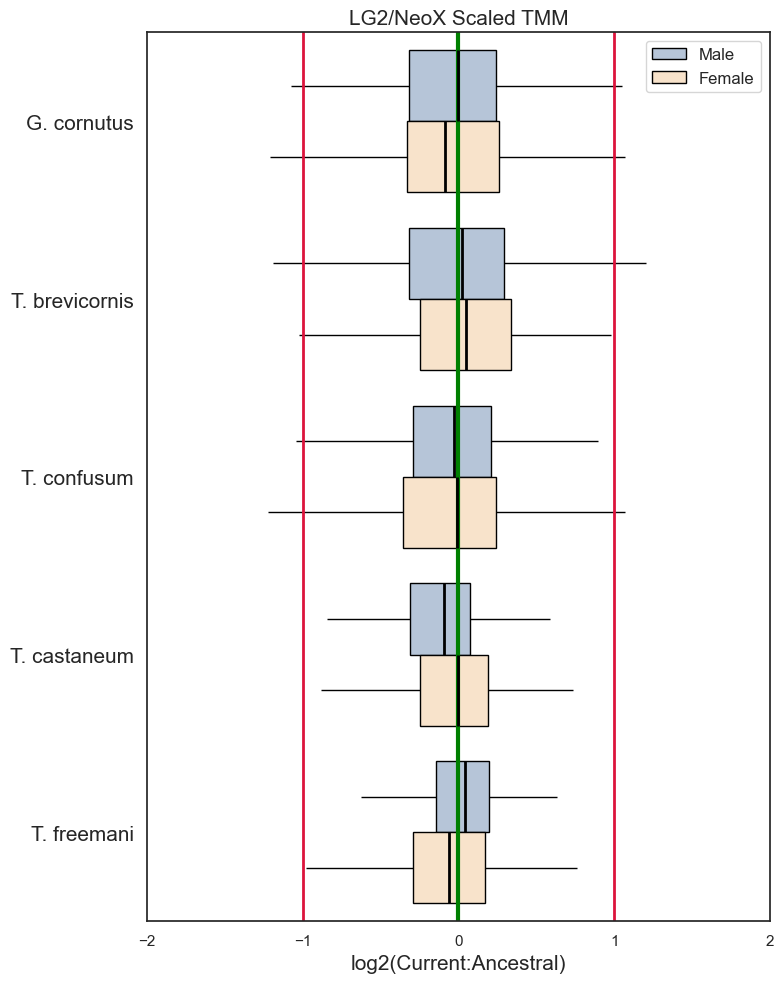

Saved: Figure_1.png


In [16]:
LG2NeoX_Robust = Combined_ACE_Robust_df[
    Combined_ACE_Robust_df['chrom_name'] == 'LG2,Neo-X'].copy()

species_order = ['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']
species_labels = {
    'G_corn': 'G. cornutus',
    'T_brev': 'T. brevicornis',
    'T_conf': 'T. confusum',
    'T_cast': 'T. castaneum',
    'T_frem': 'T. freemani'
}

LG2NeoX_Robust['species_label'] = pd.Categorical(
    LG2NeoX_Robust['species'].map(species_labels),
    categories=[species_labels[s] for s in species_order],
    ordered=True
)

palette = {'Male': 'lightsteelblue', 'Female': 'bisque'}

fig, ax = plt.subplots(figsize=(8, 10))

sns.boxplot(
    ax=ax,
    data=LG2NeoX_Robust,
    y='species_label',
    x='Robust_log2(Current:Ancestral)',
    hue='gender',
    showfliers=False,
    palette=palette,
    medianprops={'color': 'black', 'linewidth': 2},
    boxprops={'edgecolor': 'black', 'linewidth': 1},
    whiskerprops={'color': 'black', 'linewidth': 1},
    capprops={'color': 'black', 'linewidth': 0},
    linewidth=1
)

ax.set_xlim(-2, 2)
ax.set_xlabel('log2(Current:Ancestral)', size=15)
ax.set_ylabel(None)
ax.axvline(0, ls='-', color='green', lw=3)
for x in (-1, 1):
    ax.axvline(x, ls='-', color='crimson', lw=2)

ax.set_title('LG2/NeoX Scaled TMM', size=15)
ax.set_xticks(range(-2, 3, 1))
ax.tick_params(axis='y', labelsize=15)

def add_median_labels(ax, fmt='.2f'):
    lines = ax.get_lines()
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    if not boxes:
        return
    lines_per_box = int(len(lines) / len(boxes))
    for median in lines[4:len(lines):lines_per_box]:
        x, y = (arr.mean() for arr in median.get_data())
        value = x if (median.get_xdata()[1] - median.get_xdata()[0]) == 0 else y
        text = ax.text(
            x, y, f'{value:{fmt}}',
            ha='center', va='center',
            fontweight='bold', color='white'
        )
        text.set_path_effects([
            path_effects.Stroke(linewidth=3, foreground=median.get_color()),
            path_effects.Normal(),
        ])

# add_median_labels(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', prop={'size': 12}, frameon=True)

plt.tight_layout()

# Save PNG
output_file = 'Figure_1.png'
fig.savefig(output_file, dpi=300, bbox_inches='tight', format='png')

plt.show()
print(f"Saved: {output_file}")

#  Figure 1 stats: Wilcoxon for LG2,Neo-X log2(Current:Ancestral)

In [17]:
# subset Neo-X
neoX = Combined_ACE_Robust_df[Combined_ACE_Robust_df['chrom_name'] == 'LG2,Neo-X'].copy()

results = []

for (species, gender), group in neoX.groupby(['species', 'gender']):
    
    values = group['Robust_log2(Current:Ancestral)'].dropna()
    
    if len(values) == 0 or (values == 0).all():
        p = None
    else:
        try:
            _, p = wilcoxon(values, alternative='two-sided')
        except ValueError:
            p = None

    median = values.median()
    mad = (values - median).abs().median()

    results.append({
        'species': species,
        'gender': gender,
        'n': len(values),
        'median': median,
        'MAD': mad,
        'p_value': p
    })

# --- wilcoxon results ---

wilcoxon_results_df = pd.DataFrame(results)

valid = wilcoxon_results_df['p_value'].notna()

wilcoxon_results_df.loc[valid,'Bonferroni'] = multipletests(wilcoxon_results_df.loc[valid, 'p_value'],method='bonferroni')[1]

wilcoxon_results_df['gender'] = pd.Categorical(wilcoxon_results_df['gender'],categories=['Male', 'Female'],ordered=True)

wilcoxon_results_df = wilcoxon_results_df.sort_values(['species', 'gender']).reset_index(drop=True)

display(wilcoxon_results_df)

,species,gender,n,median,MAD,p_value,Bonferroni
0,G_corn,Male,420,-0.001421,0.273383,0.151286,1.000000
1,G_corn,Female,430,-0.087903,0.320471,0.001851,0.018505
2,T_brev,Male,420,0.021607,0.294893,0.904070,1.000000
3,T_brev,Female,430,0.051121,0.293983,0.101916,1.000000
4,T_cast,Male,420,-0.093018,0.192672,0.000000,0.000000
5,T_cast,Female,430,-0.004361,0.210119,0.161097,1.000000
6,T_conf,Male,420,-0.031777,0.256678,0.020274,0.202741
7,T_conf,Female,430,-0.008417,0.286702,0.019877,0.198765
8,T_frem,Male,420,0.039086,0.166192,0.041669,0.416694
9,T_frem,Female,430,-0.059321,0.232520,0.000149,0.001490


## Supplemental Analysys of C:A across all chromosomes.

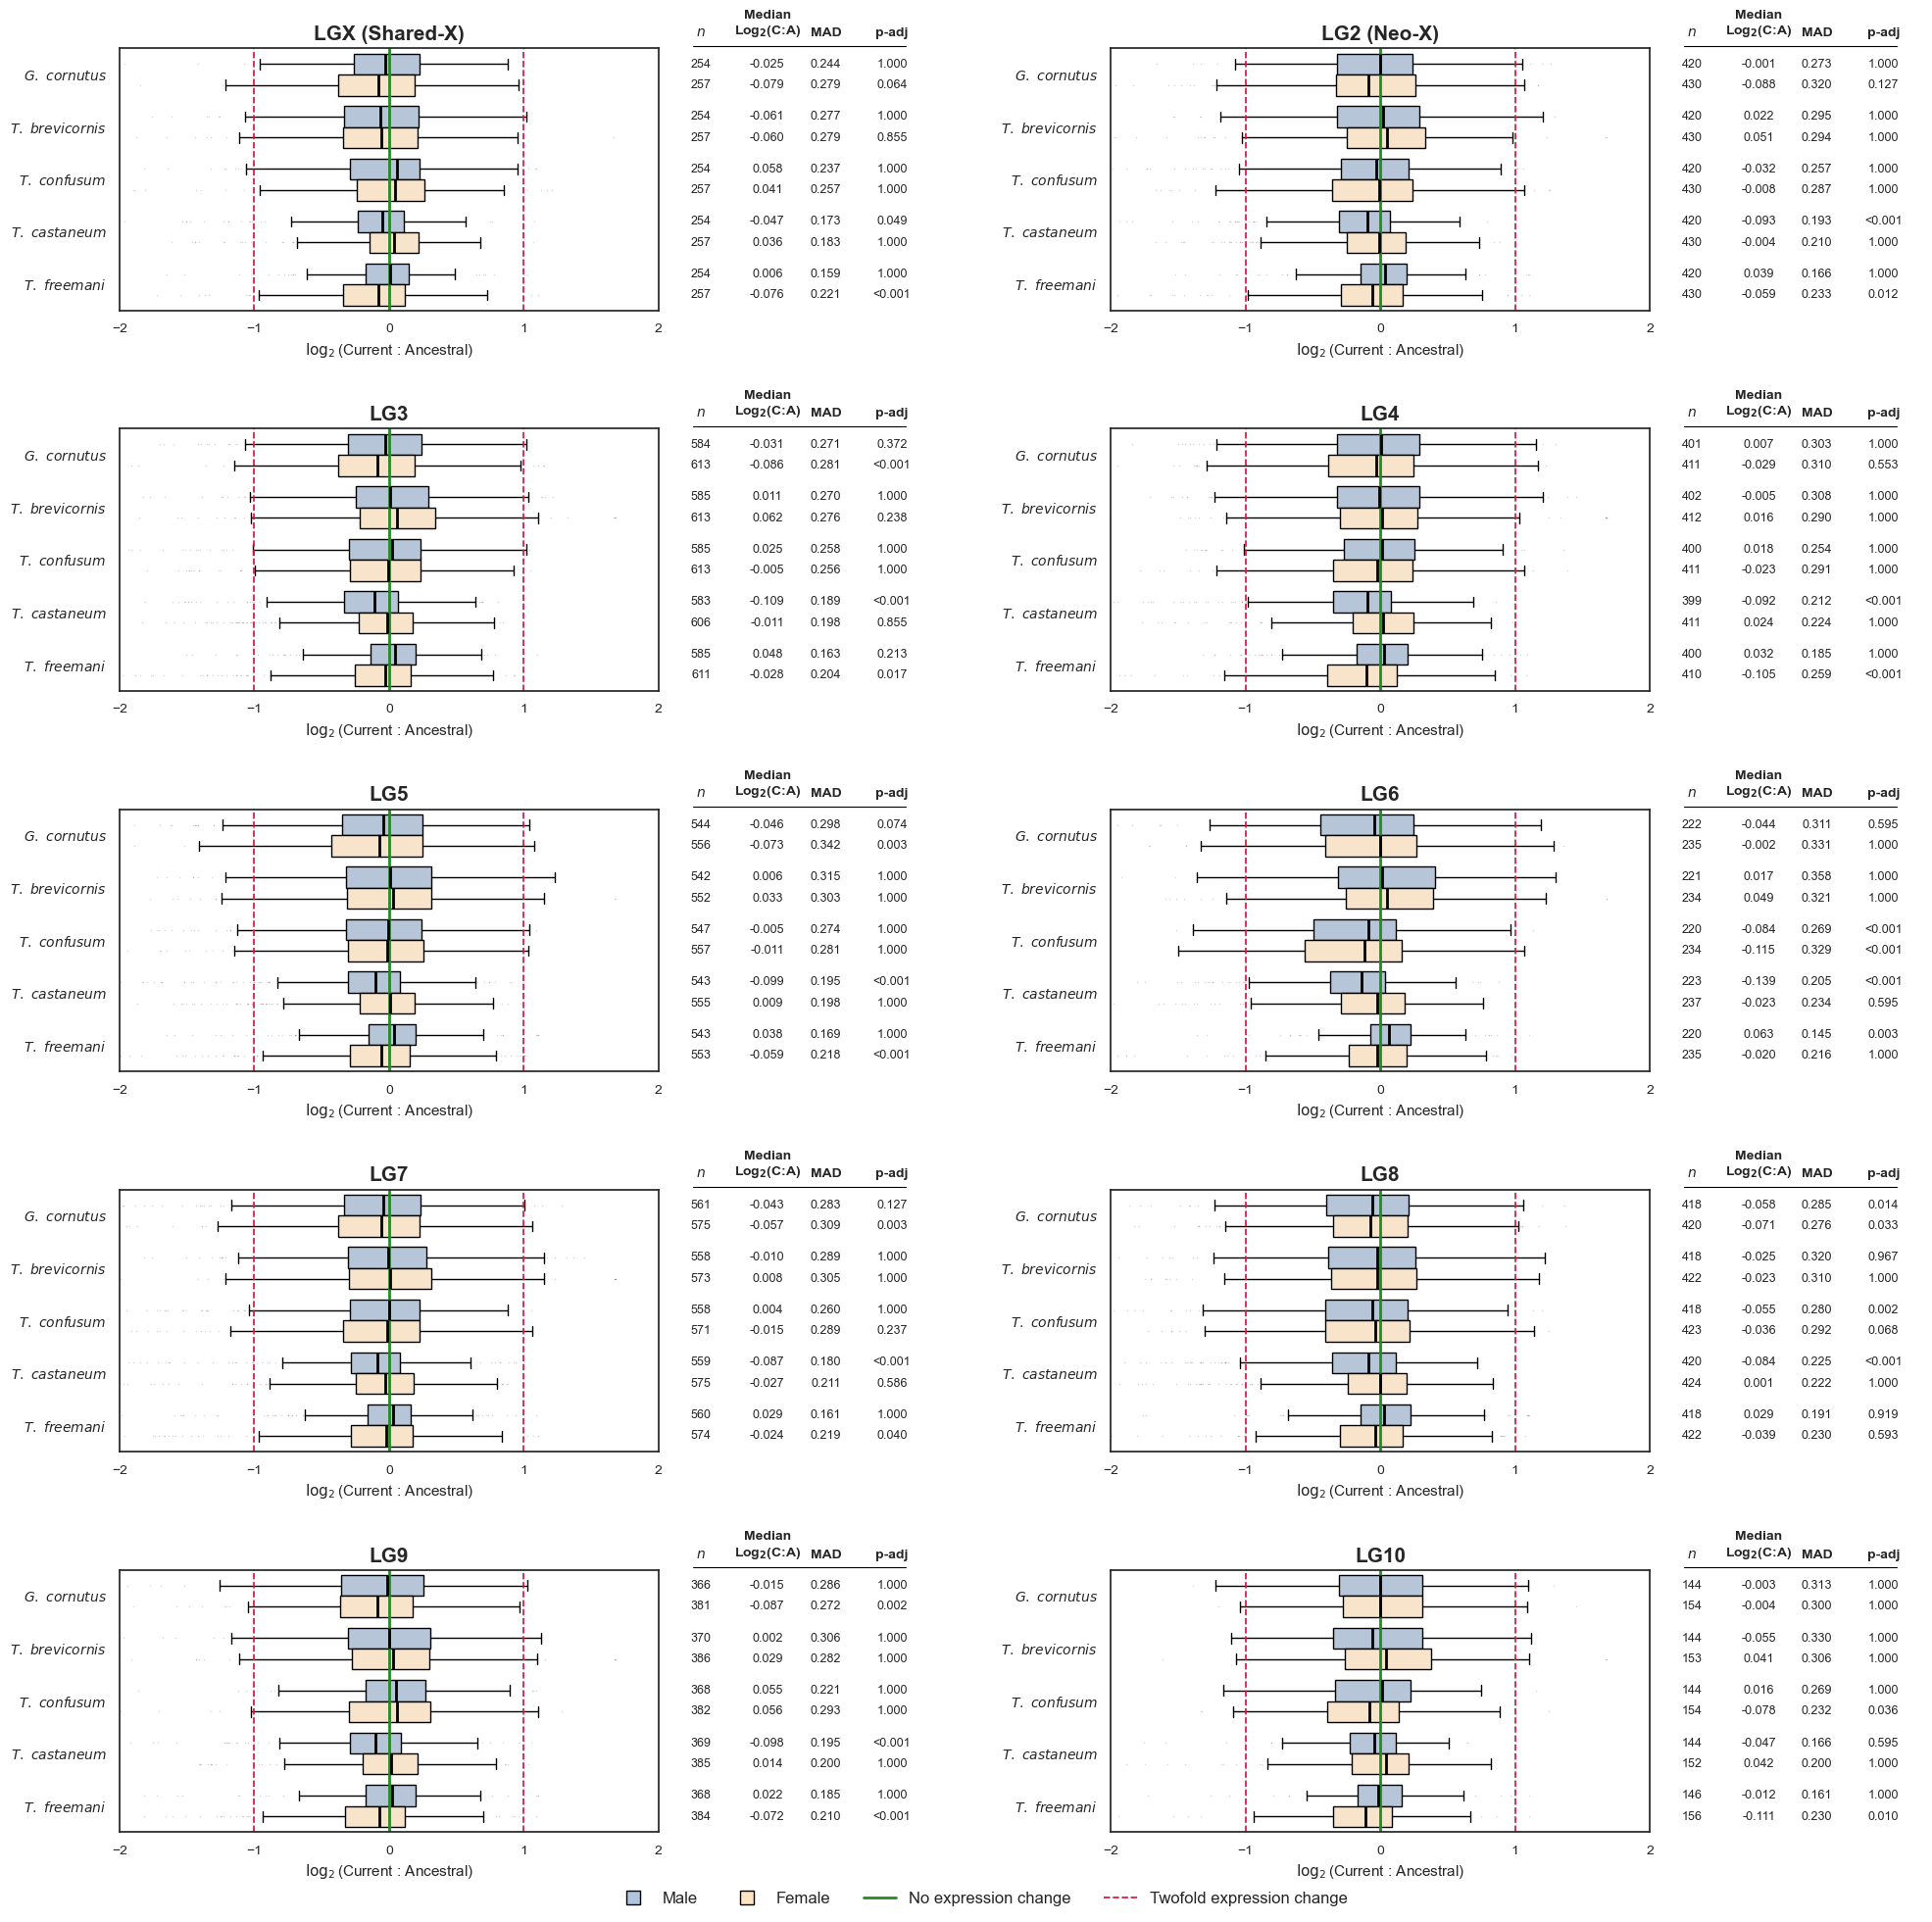

Saved: Figure_S5.png


In [18]:
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory


sns.set_style("white")

ratio_col = "Robust_log2(Current:Ancestral)"

chromosome_order = [
    "LGX", "LG2", "LG3", "LG4", "LG5",
    "LG6", "LG7", "LG8", "LG9", "LG10"
]

chromosome_titles = {
    "LGX": "LGX (Shared-X)",
    "LG2": "LG2 (Neo-X)",
    "LG3": "LG3",
    "LG4": "LG4",
    "LG5": "LG5",
    "LG6": "LG6",
    "LG7": "LG7",
    "LG8": "LG8",
    "LG9": "LG9",
    "LG10": "LG10"
}

species_order = [
    "G_corn",
    "T_brev",
    "T_conf",
    "T_cast",
    "T_frem"
]

species_labels = {
    "G_corn": r"$G.\ cornutus$",
    "T_brev": r"$T.\ brevicornis$",
    "T_conf": r"$T.\ confusum$",
    "T_cast": r"$T.\ castaneum$",
    "T_frem": r"$T.\ freemani$"
}

gender_order = ["Male", "Female"]

palette = {
    "Male": "lightsteelblue",
    "Female": "bisque"
}


# Format adjusted P values

def format_p_value(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

# Data prep

chrom_df = Combined_ACE_Robust_df[Combined_ACE_Robust_df["chrom_num"].isin(chromosome_order)].copy()
chrom_df[ratio_col] = pd.to_numeric(chrom_df[ratio_col],errors="coerce")
chrom_df = (chrom_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[ratio_col,"chrom_num","species","gender"]))
chrom_df["chrom_num"] = pd.Categorical(chrom_df["chrom_num"],categories=chromosome_order,ordered=True)
chrom_df["species_label"] = chrom_df["species"].map(species_labels)

chrom_df["species_label"] = pd.Categorical(chrom_df["species_label"],categories=[species_labels[species]for species in species_order],ordered=True)

# Calculate chromosome summary statistics

summary_rows = []

for (chromosome, species, gender), group in chrom_df.groupby(
    ["chrom_num", "species", "gender"],
    observed=True
):
    values = (
        pd.to_numeric(group[ratio_col], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        continue

    median_value = np.median(values)

    # Median absolute deviation from the group median
    mad_value = np.median(
        np.abs(values - median_value)
    )

    # Two-sided Wilcoxon signed-rank test against zero
    if np.allclose(values, 0):
        p_value = 1.0
    else:
        try:
            _, p_value = wilcoxon(
                values,
                alternative="two-sided"
            )
        except ValueError:
            p_value = np.nan

    summary_rows.append({
        "chromosome": str(chromosome),
        "species": species,
        "gender": gender,
        "n": len(values),
        "median_log2_ratio": median_value,
        "MAD": mad_value,
        "p_value": p_value
    })


chromosome_summary = pd.DataFrame(summary_rows)


# Holm correction across all chromosome × species × sex tests
chromosome_summary["p_adjusted"] = np.nan

valid_p = chromosome_summary["p_value"].notna()

chromosome_summary.loc[
    valid_p,
    "p_adjusted"
] = multipletests(
    chromosome_summary.loc[valid_p, "p_value"],
    method="holm"
)[1]


# Figure Layout

fig = plt.figure(figsize=(20, 20))

outer_grid = fig.add_gridspec(
    nrows=5,
    ncols=2,
    hspace=0.45,
    wspace=0.22
)


for panel_number, chromosome in enumerate(chromosome_order):

    row = panel_number // 2
    col = panel_number % 2

# Narrow table area
    inner_grid = outer_grid[row, col].subgridspec(
        nrows=1,
        ncols=2,
        width_ratios=[1.3, 0.64],
        wspace=0.02
    )

    ax_plot = fig.add_subplot(inner_grid[0, 0])

# Shared y-axis aligns statistics with the boxes
    ax_table = fig.add_subplot(
        inner_grid[0, 1],
        sharey=ax_plot
    )

# Boxplot

    plot_subset = chrom_df[
        chrom_df["chrom_num"] == chromosome
    ].copy()

    sns.boxplot(
        ax=ax_plot,
        data=plot_subset,
        y="species_label",
        x=ratio_col,
        hue="gender",
        hue_order=gender_order,
        order=[
            species_labels[species]
            for species in species_order
        ],
        palette=palette,
        showfliers=True,
        flierprops={
            "marker": ".",
            "markersize": 2,
            "markerfacecolor": "grey",
            "markeredgecolor": "none",
            "alpha": 0.35
        },
        medianprops={
            "color": "black",
            "linewidth": 2
        },
        boxprops={
            "edgecolor": "black",
            "linewidth": 1
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1
        },
        capprops={
            "color": "black",
            "linewidth": 1
        },
        linewidth=1
    )

    
# No change from ancestral expression
    ax_plot.axvline(
        0,
        color="forestgreen",
        linewidth=2
    )

# Twofold decrease and increase
    for x_value in (-1, 1):
        ax_plot.axvline(
            x_value,
            color="crimson",
            linestyle="--",
            linewidth=1.25
        )

    ax_plot.set_title(
        chromosome_titles[chromosome],
        fontsize=15,
        fontweight="bold"
    )

    ax_plot.set_xlabel(
        r"$\log_2$(Current : Ancestral)",
        fontsize=11
    )

    ax_plot.set_ylabel(None)

# Plot ends exactly at -2 and 2
    ax_plot.set_xlim(-2, 2)
    ax_plot.set_xticks([-2, -1, 0, 1, 2])

    ax_plot.tick_params(
        axis="both",
        labelsize=10
    )

    if ax_plot.get_legend() is not None:
        ax_plot.get_legend().remove()

# Align stats with the plot boxes

    table_subset = chromosome_summary[
        chromosome_summary["chromosome"].astype(str) == chromosome
    ].copy()

    ax_table.set_ylim(ax_plot.get_ylim())
    ax_table.set_xlim(0, 1)
    ax_table.axis("off")

# Column spacing
    column_x = {
        "N": 0.13,
        "Median": 0.38,
        "MAD": 0.60,
        "P_adj": 0.85
    }

# Column headings
    ax_table.text(
        column_x["N"],
        1.035,
        r"$n$",
        transform=ax_table.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
    ax_table.text(
        column_x["Median"],
        1.035,
        "Median\nLog" + r"$_\mathbf{2}$"+"(C:A)",
        transform=ax_table.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

    ax_table.text(
        column_x["MAD"],
        1.035,
        "MAD",
        transform=ax_table.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

    ax_table.text(
        column_x["P_adj"],
        1.035,
        "p-adj",
        transform=ax_table.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Only format line: below column headings
    ax_table.plot(
        [0.10, 0.90],
        [1.01, 1.01],
        transform=ax_table.transAxes,
        color="black",
        linewidth=0.8,
        clip_on=False
    )

# Axes coordinates horizontally and data coordinates vertically
    table_transform = blended_transform_factory(
        ax_table.transAxes,
        ax_table.transData
    )

# Offsets corresponding to the two hue boxes
    gender_offsets = {
        "Male": -0.20,
        "Female": 0.20
    }

# Add one numerical row beside each box
    for species_position, species in enumerate(species_order):

        for gender in gender_order:

            result = table_subset[
                table_subset["species"].eq(species) &
                table_subset["gender"].eq(gender)
            ]

            if result.empty:
                continue

            result = result.iloc[0]

            y_position = (
                species_position +
                gender_offsets[gender]
            )

            values_to_display = [
                (
                    column_x["N"],
                    f"{int(result['n']):,}"
                ),
                (
                    column_x["Median"],
                    f"{result['median_log2_ratio']:.3f}"
                ),
                (
                    column_x["MAD"],
                    f"{result['MAD']:.3f}"
                ),
                (
                    column_x["P_adj"],
                    format_p_value(result["p_adjusted"])
                )
            ]

            for x_position, displayed_value in values_to_display:

                ax_table.text(
                    x_position,
                    y_position,
                    displayed_value,
                    transform=table_transform,
                    ha="center",
                    va="center",
                    fontsize=9
                )


# Legend

legend_handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="lightsteelblue",
        markeredgecolor="black",
        markersize=10,
        label="Male"
    ),
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="bisque",
        markeredgecolor="black",
        markersize=10,
        label="Female"
    ),
    Line2D(
        [0], [0],
        color="forestgreen",
        linewidth=2,
        label="No expression change"
    ),
    Line2D(
        [0], [0],
        color="crimson",
        linestyle="--",
        linewidth=1.25,
        label="Twofold expression change"
    )
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=4,
    frameon=False,
    fontsize=12
)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.06,
    top=0.97
)


# Save and display

output_file = (
    "Figure_S5.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {output_file}")

# End Analysis of Single Copy Orthologs
# Begin X:XX:AA Analyses (non-orthologous gene comparisons)
* Include expressed genes (default = TMM>=1)
* Since comparisons are X:A within species, cross-species normalization not needed

In [19]:
# Filter by expression
expr = data[data['Current_TMM'] >=1].copy()
pseudocount = 0.01

# Collapse by gene ID within species + sex + chromosome
gene_expr = ( expr .groupby(['species', 'gender', 'seq_id', 'chrom_name'])['Current_TMM'] .median() .reset_index() )

# Separate NeoX(chr2), X, and autosomal genes
NeoX_genes = gene_expr[gene_expr['chrom_name'] == 'LG2,Neo-X'].copy()
X_genes = gene_expr[gene_expr['chrom_name'] == 'X'].copy()
Autosomes = gene_expr[gene_expr['chrom_name'] == 'Autosome'].copy()

# Compute median autosome expression within each species + gender
auto_medians = (Autosomes.groupby(['species', 'gender'])['Current_TMM'].median().reset_index().rename(columns={'Current_TMM': 'median_autosome_TMM'}))

# Merge autosome medians onto NeoX and X genes
NeoX_genes = NeoX_genes.merge(auto_medians,on=['species', 'gender'],how='left')
X_genes = X_genes.merge(auto_medians,on=['species', 'gender'],how='left')

# Compute log2(X : median autosome)
NeoX_genes['log2_NeoXA'] = np.log2((NeoX_genes['Current_TMM'] + pseudocount) /(NeoX_genes['median_autosome_TMM'] + pseudocount))
X_genes['log2_XA'] = np.log2((X_genes['Current_TMM'] + pseudocount) /(X_genes['median_autosome_TMM'] + pseudocount))

NeoX_summary = (
    NeoX_genes
    .groupby(['species', 'gender'])['log2_NeoXA']
    .agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    )
    .reset_index()
)

NeoX_summary['chromosome'] = 'Neo-X'


X_summary = (
    X_genes
    .groupby(['species', 'gender'])['log2_XA']
    .agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    )
    .reset_index()
)

X_summary['chromosome'] = 'X'

### Uncomment to display summary statistics for Neo- and Shared-X chromosomes
#display(NeoX_summary)
#display(X_summary)


# Figure 3A: Neo-X and Shared-X : Autosomal medians in each species

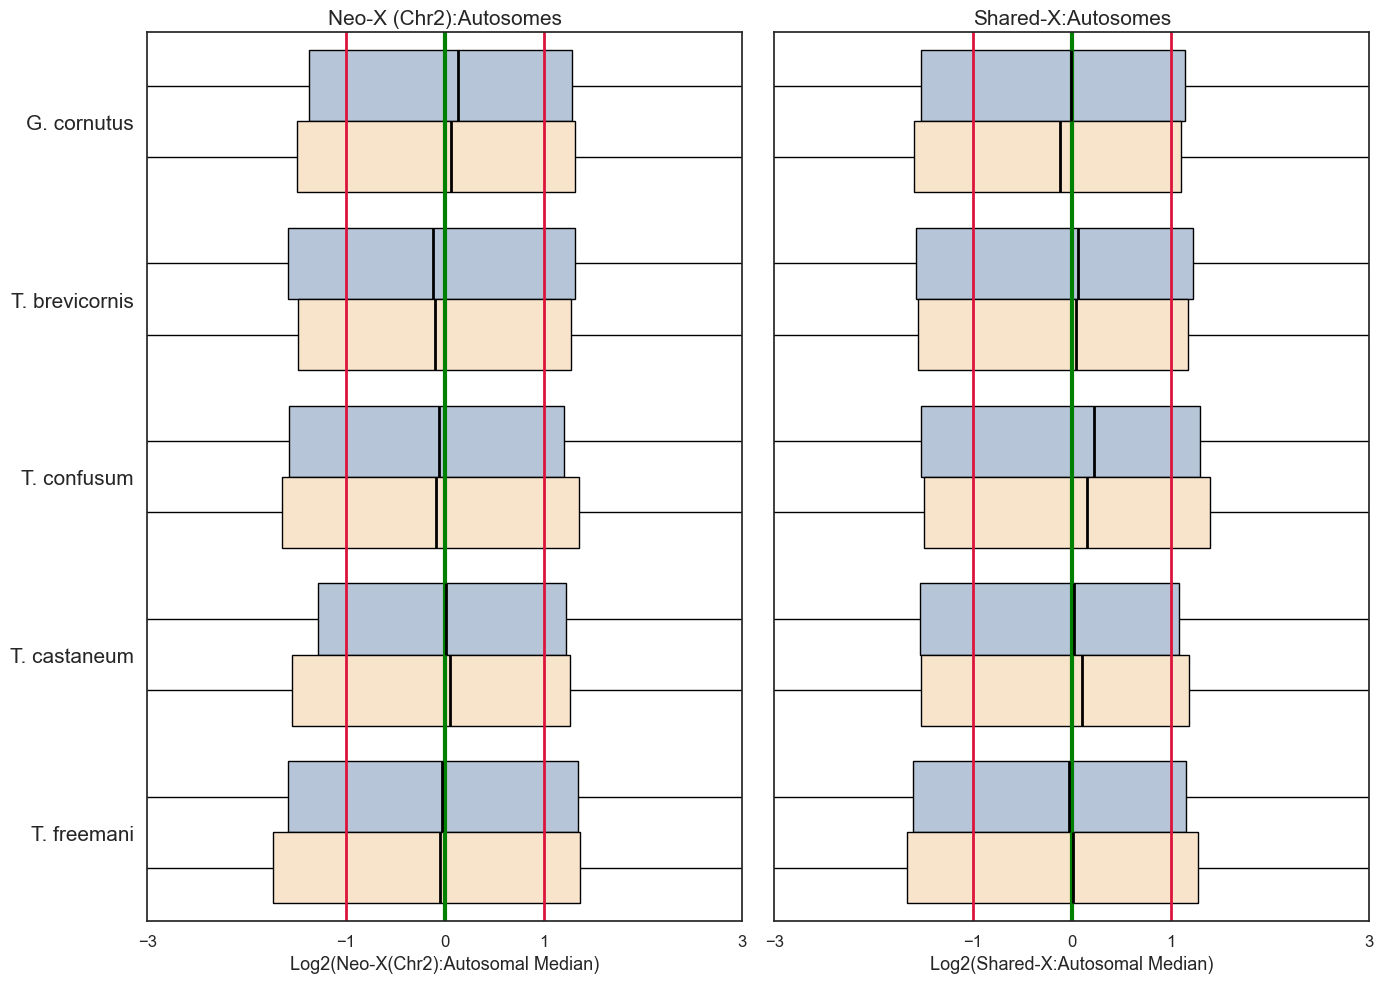

Saved: Figure_3A.png


In [20]:
NeoX_plot = NeoX_genes.copy()
NeoX_plot['chromosome'] = 'Neo-X'

SharedX_plot = X_genes.copy()
SharedX_plot['chromosome'] = 'Shared-X'

combined_plot = pd.concat([NeoX_plot,SharedX_plot],ignore_index=True)

combined_plot['log2_ratio'] = combined_plot['log2_XA']

combined_plot.loc[combined_plot['chromosome'] == 'Neo-X','log2_ratio'] = combined_plot.loc[combined_plot['chromosome'] == 'Neo-X','log2_NeoXA']

# Formatting order
species_order = ['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']

species_labels = {
    'G_corn': 'G. cornutus',
    'T_brev': 'T. brevicornis',
    'T_conf': 'T. confusum',
    'T_cast': 'T. castaneum',
    'T_frem': 'T. freemani'
}

combined_plot['species_label'] = pd.Categorical(combined_plot['species'].map(species_labels),categories=[species_labels[s] for s in species_order],ordered=True)

palette = {'Male': 'lightsteelblue','Female': 'bisque'}

fig, axes = plt.subplots(1,2,figsize=(14, 10),sharey=True)

panel_info = [
    {
        'chrom': 'Neo-X',
        'title': 'Neo-X (Chr2):Autosomes',
        'xlabel': 'Log2(Neo-X(Chr2):Autosomal Median)'
    },
    {
        'chrom': 'Shared-X',
        'title': 'Shared-X:Autosomes',
        'xlabel': 'Log2(Shared-X:Autosomal Median)'
    }
]

for ax, info in zip(axes, panel_info):

    subset = combined_plot[
        combined_plot['chromosome'] == info['chrom']
    ]

    sns.boxplot(
        ax=ax,
        data=subset,
        y='species_label',
        x='log2_ratio',
        hue='gender',
        hue_order=['Male', 'Female'],
        showfliers=False,
        palette=palette,
        medianprops={'color': 'black', 'linewidth': 2},
        boxprops={'edgecolor': 'black', 'linewidth': 1},
        whiskerprops={'color': 'black', 'linewidth': 1},
        capprops={'color': 'black', 'linewidth': 0},
        linewidth=1
    )

    ax.set_xlim(-3, 3)

    ax.set_xticks([-3, -1, 0, 1, 3])

    ax.axvline(
        0,
        ls='-',
        color='green',
        lw=3
    )

    for x in (-1, 1):
        ax.axvline(
            x,
            ls='-',
            color='crimson',
            lw=2
        )

    ax.set_title(
        info['title'],
        size=15
    )

    ax.set_xlabel(
        info['xlabel'],
        size=13
    )

    ax.tick_params(
        axis='x',
        labelsize=12
    )

    ax.tick_params(
        axis='y',
        labelsize=15
    )

    ax.legend_.remove()

axes[0].set_ylabel(None)
axes[1].set_ylabel(None)

plt.tight_layout()

output_file = 'Figure_3A.png'

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches='tight',
    format='png'
)

plt.show()

print(f"Saved: {output_file}")

## Figure 3A stats: Wilcoxon tests for compensation: Log2(Neo- or Shared-X : Autosome) = 0

In [21]:
#Neo-X summary table

summary_rows = []

for (species, gender), group in NeoX_genes.groupby(['species', 'gender']):

    values = group['log2_NeoXA'].dropna()

    n = len(values)

    median = values.median()

    # Raw MAD
    mad = (values - median).abs().median()

    # Wilcoxon signed-rank test against zero
    stat, p = wilcoxon(values)

    summary_rows.append({
        'species': species,
        'gender': gender,
        'n': n,
        'median_log2(NeoX:A)': median,
        'MAD': mad,
        'p_value': p
    })

NeoX_summary = pd.DataFrame(summary_rows)

NeoX_summary['p_adjusted'] = multipletests(NeoX_summary['p_value'],method='bonferroni')[1]

NeoX_summary['gender'] = pd.Categorical(NeoX_summary['gender'],categories=['Male', 'Female'],ordered=True)

NeoX_summary = NeoX_summary.sort_values(['species', 'gender']).reset_index(drop=True)

NeoX_summary = NeoX_summary[
    [
        'species',
        'gender',
        'n',
        'median_log2(NeoX:A)',
        'MAD',
        'p_value',
        'p_adjusted'
    ]
]

#Shared-X summary table
summary_rows = []

for (species, gender), group in X_genes.groupby(['species', 'gender']):

    values = group['log2_XA'].dropna()

    n = len(values)

    median = values.median()

    # Raw MAD
    mad = (values - median).abs().median()

    # Wilcoxon signed-rank test against zero
    stat, p = wilcoxon(values)

    summary_rows.append({
        'species': species,
        'gender': gender,
        'n': n,
        'median_log2(SharedX:A)': median,
        'MAD': mad,
        'p_value': p
    })

SharedX_summary = pd.DataFrame(summary_rows)

SharedX_summary['p_adjusted'] = multipletests(SharedX_summary['p_value'],method='bonferroni')[1]

SharedX_summary['gender'] = pd.Categorical(SharedX_summary['gender'],categories=['Male', 'Female'],ordered=True)

SharedX_summary = SharedX_summary.sort_values(['species', 'gender']).reset_index(drop=True)

SharedX_summary = SharedX_summary[
    [
        'species',
        'gender',
        'n',
        'median_log2(SharedX:A)',
        'MAD',
        'p_value',
        'p_adjusted'
    ]
]

display(NeoX_summary)
display(SharedX_summary)

,species,gender,n,median_log2(NeoX:A),MAD,p_value,p_adjusted
0,G_corn,Male,1104,0.135558,1.268730,0.724621,1.000000
1,G_corn,Female,1113,0.064499,1.374995,0.826180,1.000000
2,T_brev,Male,1169,-0.118703,1.462455,0.337976,1.000000
3,T_brev,Female,1159,-0.099916,1.378825,0.278250,1.000000
4,T_cast,Male,1197,0.014624,1.258727,0.686604,1.000000
5,T_cast,Female,1322,0.056169,1.388511,0.282323,1.000000
6,T_conf,Male,1183,-0.060716,1.429233,0.183405,1.000000
7,T_conf,Female,1174,-0.085010,1.503933,0.302309,1.000000
8,T_frem,Male,1263,-0.023531,1.502575,0.272425,1.000000
9,T_frem,Female,1297,-0.051133,1.538925,0.280560,1.000000


,species,gender,n,median_log2(SharedX:A),MAD,p_value,p_adjusted
0,G_corn,Male,722,-0.012891,1.312715,0.167093,1.000000
1,G_corn,Female,718,-0.121404,1.339865,0.020379,0.203793
2,T_brev,Male,729,0.057214,1.435129,0.387858,1.000000
3,T_brev,Female,717,0.040207,1.388477,0.232612,1.000000
4,T_cast,Male,769,0.016873,1.288758,0.076222,0.762217
5,T_cast,Female,822,0.102215,1.319623,0.271135,1.000000
6,T_conf,Male,752,0.225523,1.355835,0.906620,1.000000
7,T_conf,Female,738,0.153282,1.457879,0.400325,1.000000
8,T_frem,Male,762,-0.032041,1.336400,0.055599,0.555995
9,T_frem,Female,776,0.006639,1.427986,0.342924,1.000000


# Figure 3B: Log2(Male:Female) for each chromosome type

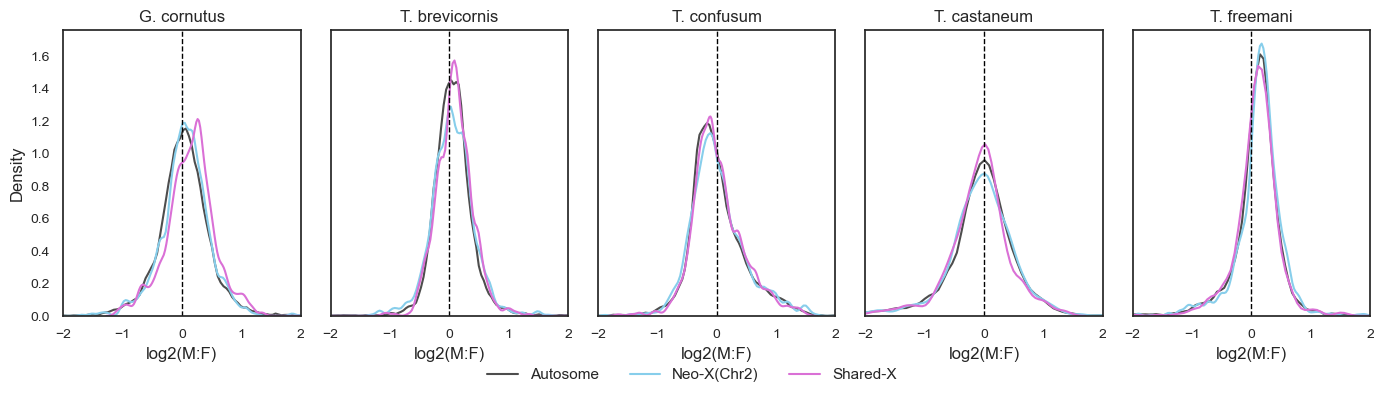

Saved: Figure_3B.png


In [22]:
fig3b_df = (
    gene_expr
    .pivot_table(
        index=['species', 'seq_id', 'chrom_name'],
        columns='gender',
        values='Current_TMM',
        aggfunc='median'
    )
    .reset_index()
)

fig3b_df = fig3b_df.dropna(subset=['Male', 'Female']).copy()

pseudocount = 0.01

fig3b_df['log2_MF'] = np.log2(
    (fig3b_df['Male'] + pseudocount) /
    (fig3b_df['Female'] + pseudocount)
)

# Keep and label chromosome categories
fig3b_df = fig3b_df[fig3b_df['chrom_name'].isin(['Autosome', 'LG2,Neo-X', 'X'])].copy()

fig3b_df['chrom_label'] = fig3b_df['chrom_name'].map({'Autosome': 'Autosome','LG2,Neo-X': 'Neo-X(Chr2)','X': 'Shared-X'})

# Species formatting

species_order = ['G_corn', 'T_brev', 'T_conf', 'T_cast', 'T_frem']

species_titles = {
    'G_corn': 'G. cornutus',
    'T_brev': 'T. brevicornis',
    'T_conf': 'T. confusum',
    'T_cast': 'T. castaneum',
    'T_frem': 'T. freemani'
}

fig3b_df['species'] = pd.Categorical(fig3b_df['species'],categories=species_order,ordered=True)

chrom_order = ['Autosome', 'Neo-X(Chr2)', 'Shared-X']

palette = {'Autosome': '#4D4D4D','Neo-X(Chr2)': 'skyblue','Shared-X': 'orchid'}

fig, axes = plt.subplots(
    1,
    len(species_order),
    figsize=(14, 4),
    sharex=True,
    sharey=True
)

for ax, species in zip(axes, species_order):

    subset = fig3b_df[fig3b_df['species'] == species].copy()

    for chrom in chrom_order:

        chrom_subset = subset[subset['chrom_label'] == chrom]

        sns.kdeplot(
            data=chrom_subset,
            x='log2_MF',
            ax=ax,
            color=palette[chrom],
            linewidth=1.5,
            bw_adjust=0.5,
            fill=False,
            label=chrom
        )

        #median_val = chrom_subset['log2_MF'].median()

        #if pd.notna(median_val):
        #    ax.axvline(
        #        median_val,
        #        color=palette[chrom],
        #        linestyle='--',
        #        linewidth=1.5,
        #        alpha=0.9
        #    )

    ax.axvline(
        0,
        color='black',
        linestyle='--',
        linewidth=1
    )

    ax.set_xlim(-2, 2)
    ax.set_xticks([-2, -1, 0, 1, 2])

    ax.set_title(
        species_titles[species],
        fontsize=12
    )

    ax.set_xlabel('log2(M:F)')
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

axes[0].set_ylabel('Density')

for ax in axes[1:]:
    ax.set_ylabel(None)

# Legend across bottom

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# Write to file

output_file = 'Figure_3B.png'

fig.savefig(output_file,dpi=300,bbox_inches='tight',format='png')

plt.show()

print(f"Saved: {output_file}")

# Figure 3B stats: Mann-Whitney for compensation for balance (X:XX)
## subsample autosomes to match neo or shared-X

In [23]:
n_iter = 1000
random_seed = 123

rng = np.random.default_rng(random_seed)

subsample_results = []

for species, subset in fig3b_df.groupby('species', observed=True):

    auto = subset.loc[subset['chrom_label'] == 'Autosome', 'log2_MF'].dropna().abs()

    chrom_sets = {'Neo-X(Chr2)': subset.loc[subset['chrom_label'] == 'Neo-X(Chr2)','log2_MF'].dropna().abs(),'Shared-X': subset.loc[subset['chrom_label'] == 'Shared-X','log2_MF'].dropna().abs()}

    for chrom_label, x_vals in chrom_sets.items():

        n_x = len(x_vals)

        if n_x == 0 or len(auto) < n_x:
            continue

        for i in range(n_iter):

            auto_sub = auto.sample(n=n_x,replace=False,random_state=int(rng.integers(0, 1_000_000_000)))

            stat, p = mannwhitneyu(x_vals,auto_sub,alternative='two-sided')

            subsample_results.append({
                'species': species,
                'comparison': f'{chrom_label} vs Autosome',
                'iteration': i,
                'n_X': n_x,
                'n_A_subsampled': len(auto_sub),
                'median_abs_X': x_vals.median(),
                'median_abs_A_subsampled': auto_sub.median(),
                'difference_X_minus_A': x_vals.median() - auto_sub.median(),
                'wilcoxon_stat': stat,
                'p_value': p
            })

subsample_results = pd.DataFrame(subsample_results)

subsample_summary = (
    subsample_results
    .groupby(['species', 'comparison'])
    .agg(
        n_X=('n_X', 'first'),
        median_difference=('difference_X_minus_A', 'median'),
        lower_95_difference=('difference_X_minus_A', lambda x: np.quantile(x, 0.025)),
        upper_95_difference=('difference_X_minus_A', lambda x: np.quantile(x, 0.975)),
        median_p=('p_value', 'median'),
        prop_p_lt_0_05=('p_value', lambda x: (x < 0.05).mean())
    )
    .reset_index()
)

display(subsample_summary)

,species,comparison,n_X,median_difference,lower_95_difference,upper_95_difference,median_p,prop_p_lt_0_05
0,G_corn,Neo-X(Chr2) vs Autosome,1069,-0.011094,-0.027023,0.003862,0.580026,0.010000
1,G_corn,Shared-X vs Autosome,695,0.034597,0.015372,0.054444,0.013847,0.782000
2,T_brev,Neo-X(Chr2) vs Autosome,1086,0.037953,0.025055,0.047986,0.000275,0.993000
3,T_brev,Shared-X vs Autosome,681,0.011735,-0.004034,0.025302,0.233574,0.133000
4,T_cast,Neo-X(Chr2) vs Autosome,1181,0.029028,0.007561,0.047227,0.344987,0.063000
5,T_cast,Shared-X vs Autosome,756,-0.024681,-0.051313,0.000344,0.099975,0.297000
6,T_conf,Neo-X(Chr2) vs Autosome,1149,0.005858,-0.010612,0.022039,0.408928,0.048000
7,T_conf,Shared-X vs Autosome,727,-0.009616,-0.029730,0.013200,0.528271,0.025000
8,T_frem,Neo-X(Chr2) vs Autosome,1223,0.019364,0.003963,0.031023,0.047578,0.513000
9,T_frem,Shared-X vs Autosome,737,-0.009629,-0.027991,0.006569,0.204133,0.152000


## Test whether neo or sharedX regions differ from log2(M:F)=0 

In [24]:

zero_test_results = []

for species, subset in fig3b_df.groupby('species', observed=True):

    chrom_sets = {
        'Neo-X(Chr2)': subset.loc[
            subset['chrom_label'] == 'Neo-X(Chr2)',
            'log2_MF'
        ].dropna(),

        'Shared-X': subset.loc[
            subset['chrom_label'] == 'Shared-X',
            'log2_MF'
        ].dropna()
    }

    for chrom_label, values in chrom_sets.items():

        if len(values) == 0:
            continue

        median = values.median()
        mad = (values - median).abs().median()

        stat, p = wilcoxon(
            values,
            alternative='two-sided'
        )

        zero_test_results.append({
            'species': species,
            'chrom_label': chrom_label,
            'n': len(values),
            'median_log2(M:F)': median,
            'MAD': mad,
            'wilcoxon_stat': stat,
            'p_value': p
        })

zero_test_results = pd.DataFrame(zero_test_results)

# Bonferroni correction

zero_test_results['p_bonferroni'] = multipletests(
    zero_test_results['p_value'],
    method='bonferroni'
)[1]

display(zero_test_results)

,species,chrom_label,n,median_log2(M:F),MAD,wilcoxon_stat,p_value,p_bonferroni
0,G_corn,Neo-X(Chr2),1069,0.064510,0.229012,233205.000000,0.000000,0.000002
1,G_corn,Shared-X,695,0.163680,0.240161,71244.000000,0.000000,0.000000
2,T_brev,Neo-X(Chr2),1086,0.048291,0.216014,239634.000000,0.000000,0.000001
3,T_brev,Shared-X,681,0.084154,0.199589,78858.000000,0.000000,0.000000
4,T_conf,Neo-X(Chr2),1149,-0.050159,0.253300,319883.000000,0.352762,1.000000
5,T_conf,Shared-X,727,-0.050311,0.234688,130562.000000,0.757096,1.000000
6,T_cast,Neo-X(Chr2),1181,-0.041848,0.314655,312352.000000,0.001779,0.017794
7,T_cast,Shared-X,756,-0.046438,0.263006,119099.000000,0.000066,0.000657
8,T_frem,Neo-X(Chr2),1223,0.164492,0.167283,188002.000000,0.000000,0.000000
9,T_frem,Shared-X,737,0.114489,0.163416,83024.000000,0.000000,0.000000


## Direct test: Neo-X vs Shared-X in T. confusum

In [25]:

tconf = fig3b_df[
    fig3b_df['species'] == 'T_conf'
].copy()

neox_tconf = (
    tconf.loc[
        tconf['chrom_label'] == 'Neo-X(Chr2)',
        'log2_MF'
    ]
    .dropna()
    .abs()
)

sharedx_tconf = (
    tconf.loc[
        tconf['chrom_label'] == 'Shared-X',
        'log2_MF'
    ]
    .dropna()
    .abs()
)

stat, p = mannwhitneyu(
    neox_tconf,
    sharedx_tconf,
    alternative='two-sided'
)

tconf_neox_vs_sharedx = pd.DataFrame([{
    'species': 'T_conf',
    'comparison': 'Neo-X(Chr2) vs Shared-X',
    'n_NeoX': len(neox_tconf),
    'n_SharedX': len(sharedx_tconf),
    'median_abs_NeoX': neox_tconf.median(),
    'median_abs_SharedX': sharedx_tconf.median(),
    'difference_NeoX_minus_SharedX': (
        neox_tconf.median() - sharedx_tconf.median()
    ),
    'mannwhitneyu_stat': stat,
    'p_value': p
}])

display(tconf_neox_vs_sharedx)

,species,comparison,n_NeoX,n_SharedX,median_abs_NeoX,median_abs_SharedX,difference_NeoX_minus_SharedX,mannwhitneyu_stat,p_value
0,T_conf,Neo-X(Chr2) vs Shared-X,1149,727,0.269238,0.254173,0.015065,433438.000000,0.167539


# Figure 4: Distribution of lethality across chromosomes
* reads in ToD data

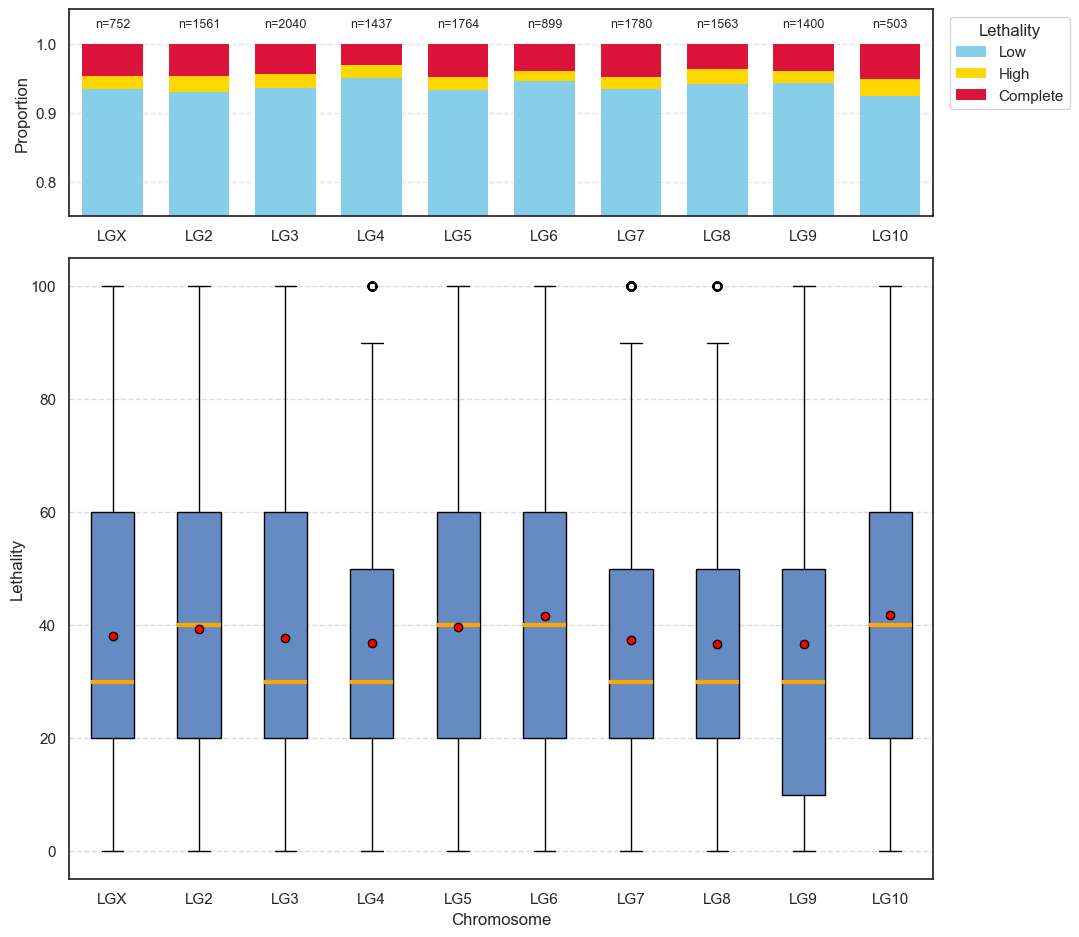

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec

# Read data
df = pd.read_csv("ToD_Fig4_data.csv")

# Clean up strings
df["chr"] = df["chr"].str.strip()
df["lethality"] = df["lethality"].str.strip().str.lower()

# Chromosome order
chromosome_order = [
    "LGX", "LG2", "LG3", "LG4", "LG5",
    "LG6", "LG7", "LG8", "LG9", "LG10"
]
chromosomes_present = [
    chrom for chrom in chromosome_order
    if chrom in df["chr"].values
]
x = range(len(chromosomes_present))

# Lethality categories
ordered_categories = ["low", "high", "yes"]
colors = {
    "low":  "skyblue",  # light blue, bottom
    "high": "gold",   # orange, middle
    "yes":  "crimson"   # red, top (complete)
}

# Compute counts and proportions
lethality_counts = (
    df.groupby(["chr", "lethality"])
      .size()
      .unstack(fill_value=0)
)

# Ensure that all plotted categories exist
for category in ordered_categories:
    if category not in lethality_counts.columns:
        lethality_counts[category] = 0

plotted_counts = lethality_counts[ordered_categories]

lethality_props = plotted_counts.div(
    plotted_counts.sum(axis=1),
    axis=0
)

lethality_props = (
    lethality_props
    .reindex(chromosomes_present)
    .fillna(0)
)

totals = (
    plotted_counts
    .sum(axis=1)
    .reindex(chromosomes_present)
)

# Figure layout
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(
    2,
    1,
    height_ratios=[1, 3],
    hspace=0.1
)

# Top panel: stacked bar plot
ax0 = plt.subplot(gs[0])
bottom = None

for category in ordered_categories:
    values = lethality_props[category].values

    ax0.bar(
        x,
        values,
        bottom=bottom,
        label=category,
        color=colors[category],
        edgecolor="none",
        linewidth=0,
        antialiased=False,
        width=0.7
    )

    bottom = values if bottom is None else bottom + values

# Annotate sample sizes
for xpos, total in zip(x, totals):
    ax0.text(
        xpos,
        1.02,
        f"n={total}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax0.set_ylabel("Proportion")
ax0.set_xticks(list(x))
ax0.set_xticklabels(chromosomes_present)
ax0.set_ylim(0.75, 1.05)
#ax0.set_title("Lethality Categories per Chromosome")

handles, labels = ax0.get_legend_handles_labels()

label_map = {
    "low": "Low",
    "high": "High",
    "yes": "Complete"
}

labels = [label_map[label] for label in labels]

ax0.legend(
    handles,
    labels,
    title="Lethality",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

ax0.grid(axis="y", linestyle="--", alpha=0.5)



####### Bottom panel: box plot #########

lethality = [
    df.loc[df["chr"] == chrom, "dali11"]
      .dropna()
      .astype(float)
    for chrom in chromosomes_present
]

ax1 = plt.subplot(gs[1], sharex=ax0)

ax1.boxplot(
    lethality,
    positions=list(x),
    labels=chromosomes_present,
    patch_artist=True,
    showmeans=True,
    boxprops={
        "facecolor": "#658BC2",
        "edgecolor": "black"
    },
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markeredgewidth": 1
    },
    medianprops={
        "color": "orange",
        "linewidth": 3
    }
)

ax1.set_xlabel("Chromosome")
ax1.set_ylabel("Lethality")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Layout, save, and display
fig.subplots_adjust(
    left=0.10,
    right=0.82,
    bottom=0.08,
    top=0.95,
    hspace=0.10
)

plt.savefig(
    "Figure_4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Tcas | Male | Autosome: n=1408, slope=0.0004, intercept=-0.3445, R²=0.0006, p=3.467e-01, SE=0.0004
Tcas | Male | LG2,Neo-X: n=173, slope=0.0016, intercept=-0.3796, R²=0.0193, p=6.798e-02, SE=0.0009
Tcas | Male | X: n=98, slope=0.0004, intercept=-0.4134, R²=0.0002, p=8.805e-01, SE=0.0027


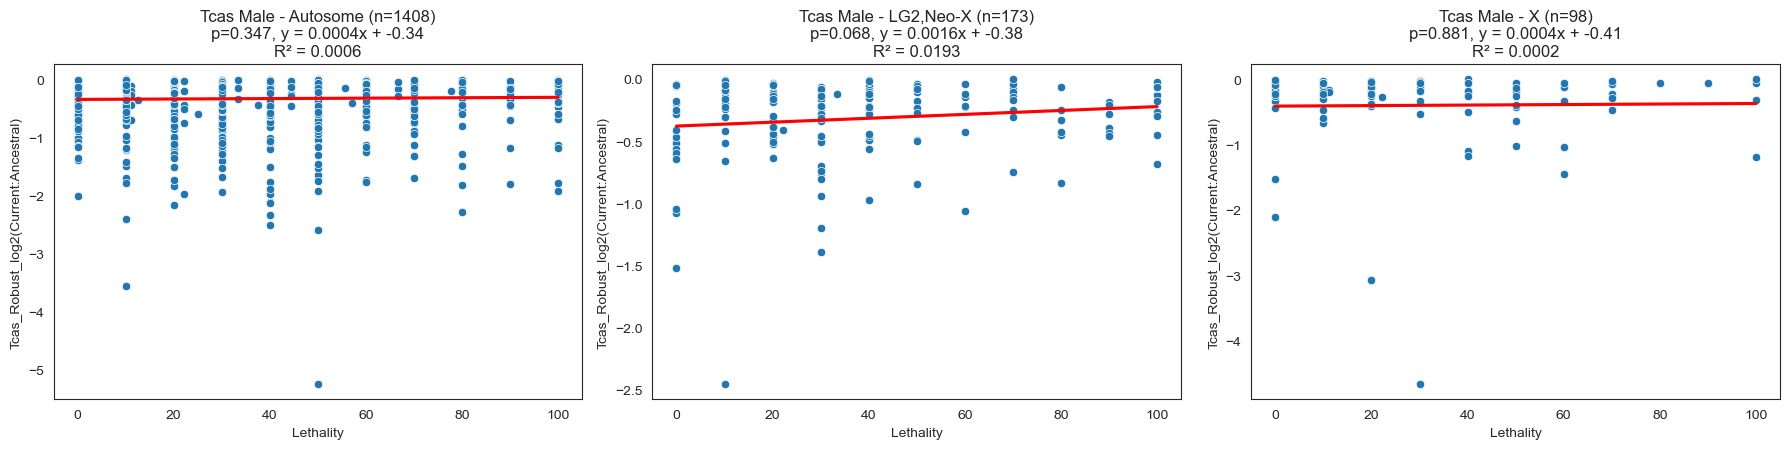

Tcas | Female | Autosome: n=1072, slope=0.0002, intercept=-0.3253, R²=0.0002, p=6.556e-01, SE=0.0005
Tcas | Female | LG2,Neo-X: n=137, slope=0.0013, intercept=-0.3912, R²=0.0023, p=5.761e-01, SE=0.0024
Tcas | Female | X: n=75, slope=0.0009, intercept=-0.4733, R²=0.0009, p=7.989e-01, SE=0.0034


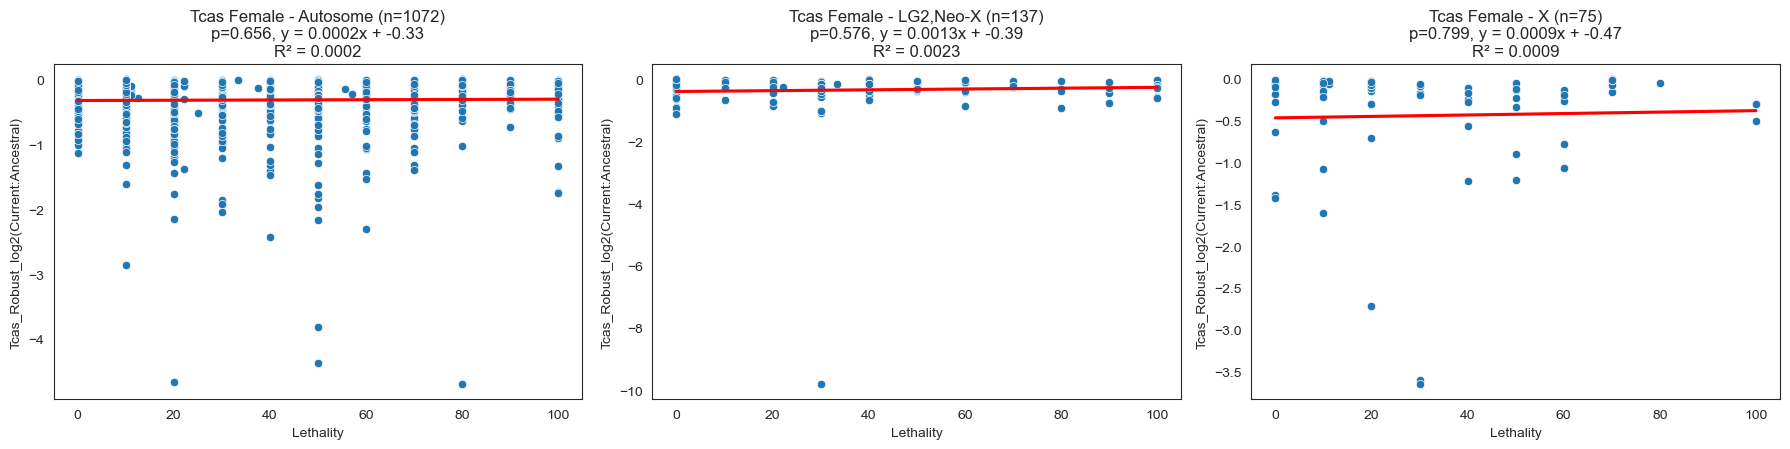

Tcon | Male | Autosome: n=1102, slope=0.0028, intercept=-0.8056, R²=0.0033, p=5.797e-02, SE=0.0015
Tcon | Male | LG2,Neo-X: n=137, slope=-0.0052, intercept=-0.4925, R²=0.0130, p=1.843e-01, SE=0.0039
Tcon | Male | X: n=79, slope=0.0010, intercept=-0.6421, R²=0.0007, p=8.211e-01, SE=0.0042


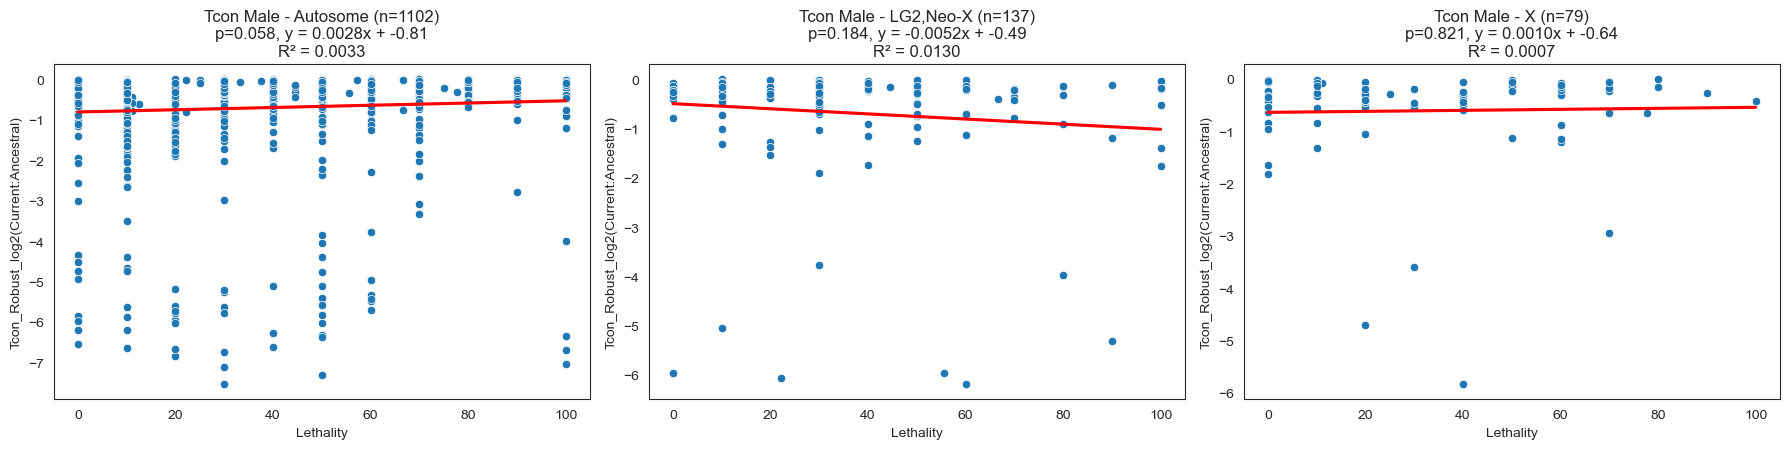

Tcon | Female | Autosome: n=1158, slope=0.0022, intercept=-0.7832, R²=0.0023, p=1.031e-01, SE=0.0013
Tcon | Female | LG2,Neo-X: n=141, slope=-0.0021, intercept=-0.6200, R²=0.0022, p=5.815e-01, SE=0.0038
Tcon | Female | X: n=79, slope=0.0001, intercept=-0.7040, R²=0.0000, p=9.833e-01, SE=0.0055


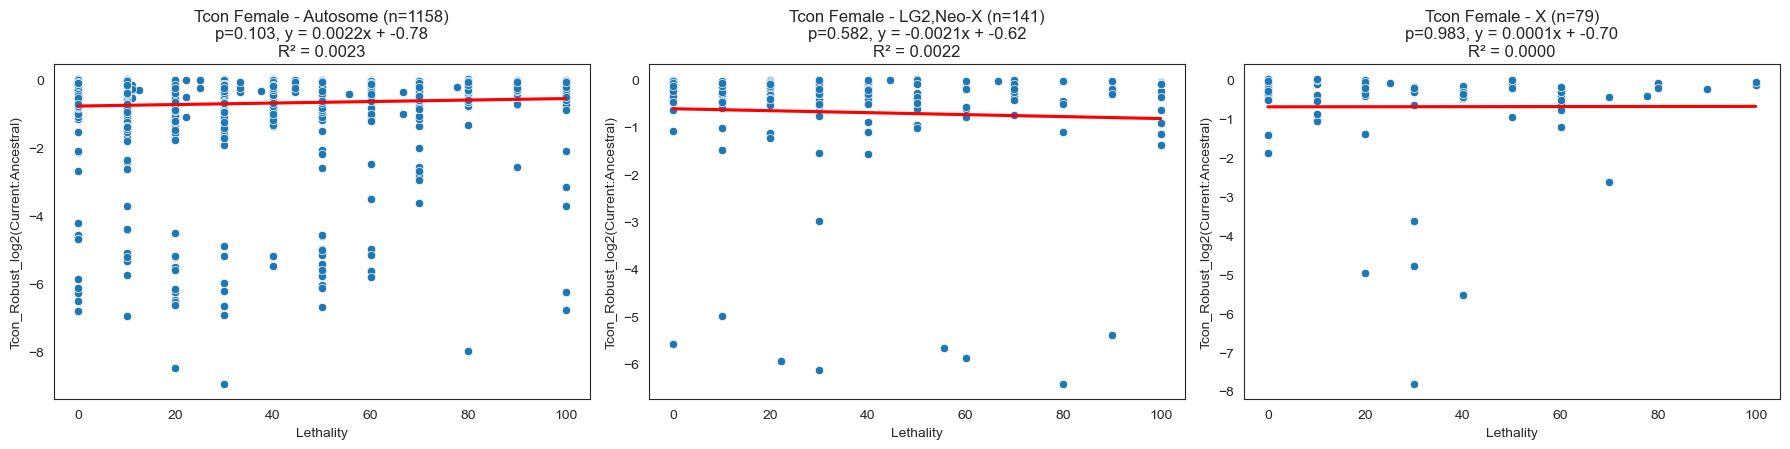

Tfrem | Male | Autosome: n=1014, slope=-0.0007, intercept=-0.2569, R²=0.0032, p=7.142e-02, SE=0.0004
Tfrem | Male | LG2,Neo-X: n=112, slope=0.0008, intercept=-0.2711, R²=0.0129, p=2.336e-01, SE=0.0007
Tfrem | Male | X: n=87, slope=-0.0035, intercept=-0.1917, R²=0.0274, p=1.254e-01, SE=0.0023


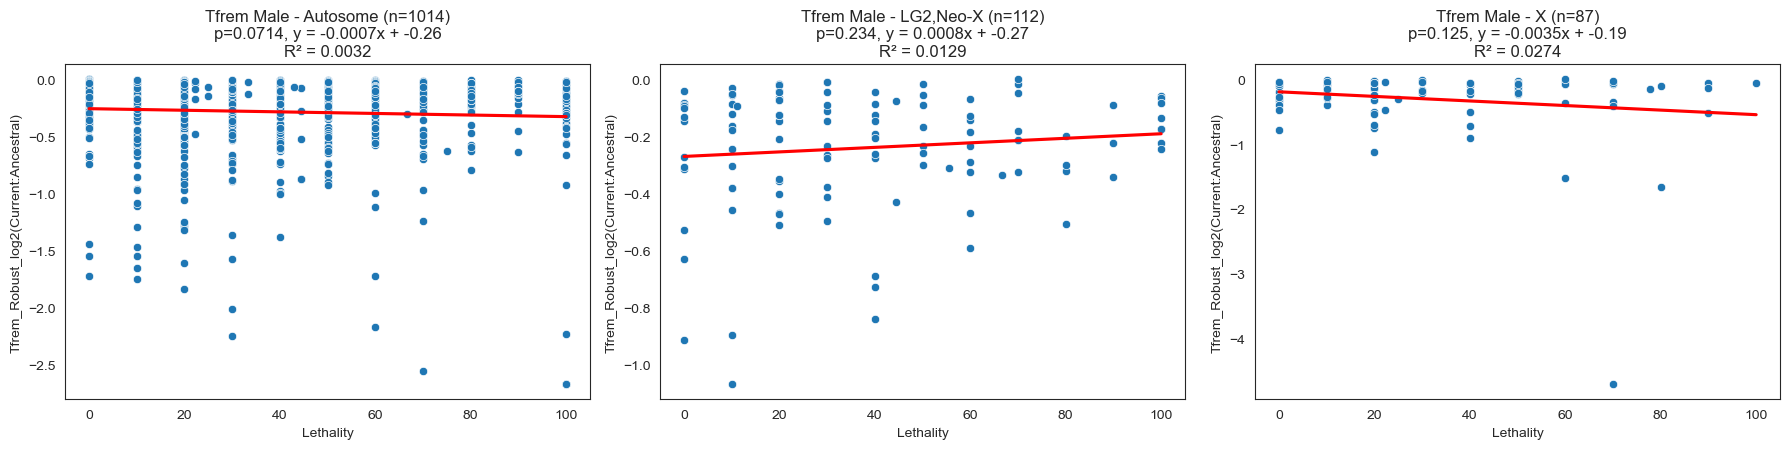

Tfrem | Female | Autosome: n=1288, slope=-0.0002, intercept=-0.3853, R²=0.0001, p=7.086e-01, SE=0.0005
Tfrem | Female | LG2,Neo-X: n=147, slope=0.0008, intercept=-0.4200, R²=0.0028, p=5.235e-01, SE=0.0013
Tfrem | Female | X: n=105, slope=-0.0013, intercept=-0.3565, R²=0.0044, p=5.018e-01, SE=0.0020


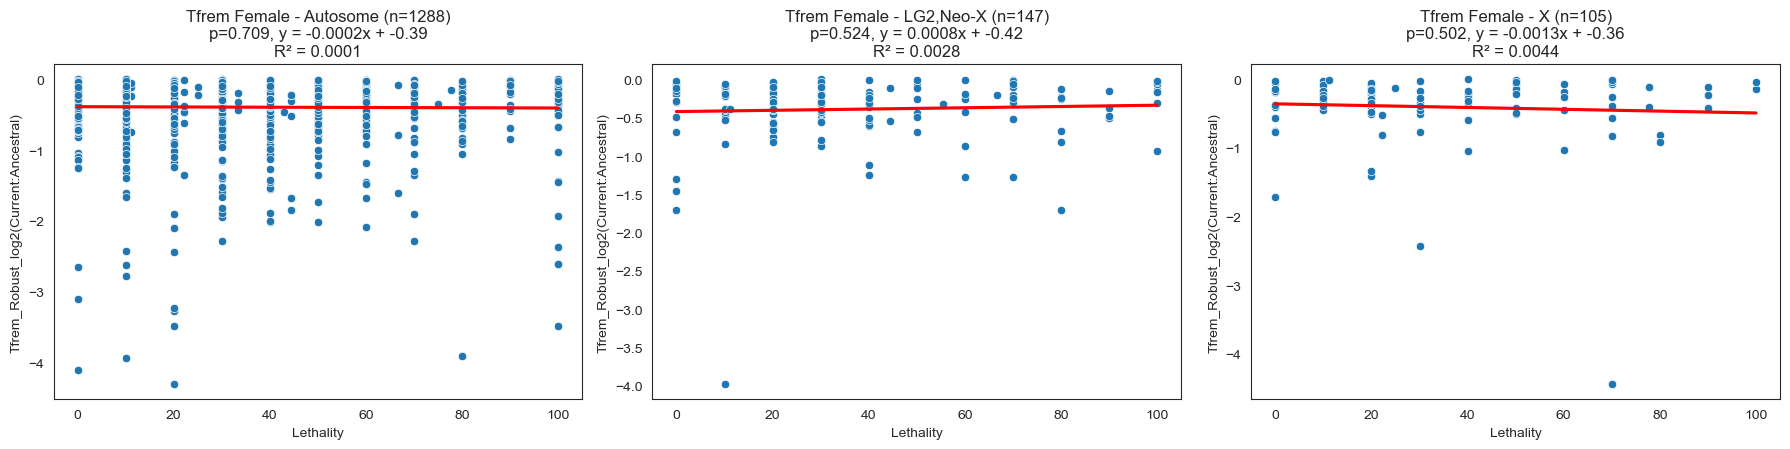

Tbrev | Male | Autosome: n=1135, slope=0.0025, intercept=-0.7070, R²=0.0044, p=2.500e-02, SE=0.0011
Tbrev | Male | LG2,Neo-X: n=126, slope=-0.0007, intercept=-0.5994, R²=0.0004, p=8.246e-01, SE=0.0032
Tbrev | Male | X: n=91, slope=-0.0015, intercept=-0.4638, R²=0.0032, p=5.931e-01, SE=0.0027


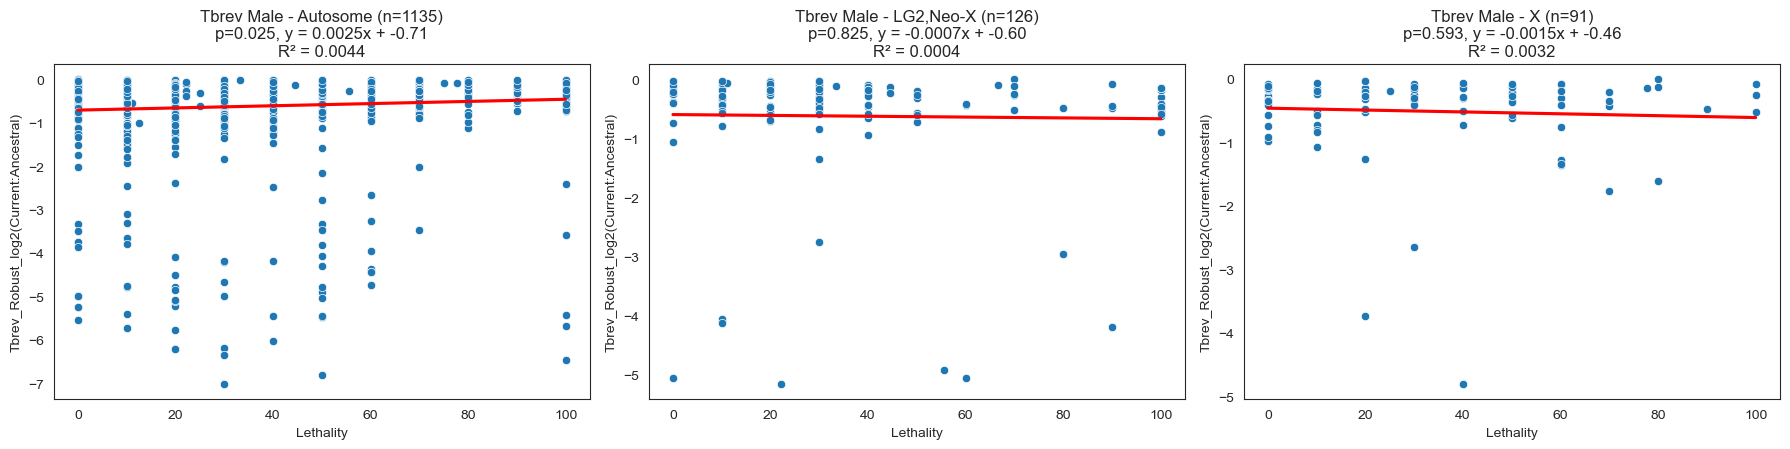

Tbrev | Female | Autosome: n=1108, slope=0.0026, intercept=-0.7168, R²=0.0046, p=2.424e-02, SE=0.0012
Tbrev | Female | LG2,Neo-X: n=126, slope=-0.0013, intercept=-0.6217, R²=0.0011, p=7.149e-01, SE=0.0036
Tbrev | Female | X: n=95, slope=-0.0014, intercept=-0.5797, R²=0.0011, p=7.542e-01, SE=0.0043


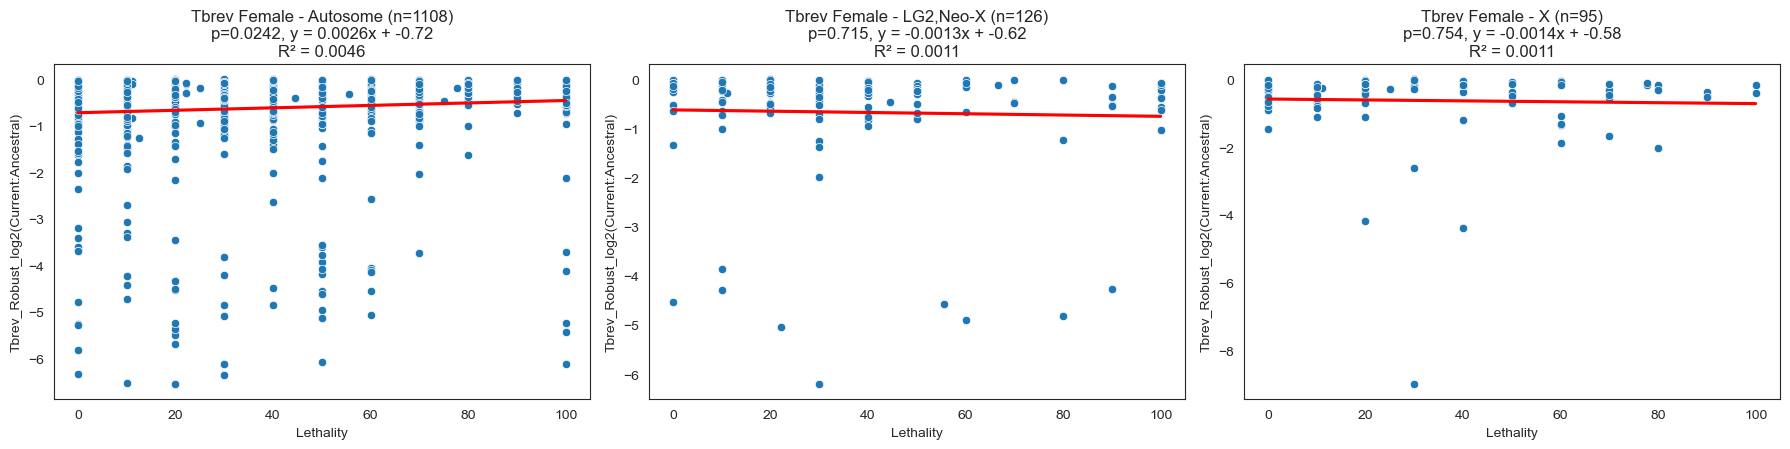

Gcorn | Male | Autosome: n=1192, slope=0.0028, intercept=-0.8497, R²=0.0035, p=4.109e-02, SE=0.0014
Gcorn | Male | LG2,Neo-X: n=137, slope=0.0008, intercept=-0.6872, R²=0.0004, p=8.198e-01, SE=0.0034
Gcorn | Male | X: n=93, slope=-0.0032, intercept=-0.3991, R²=0.0104, p=3.302e-01, SE=0.0033


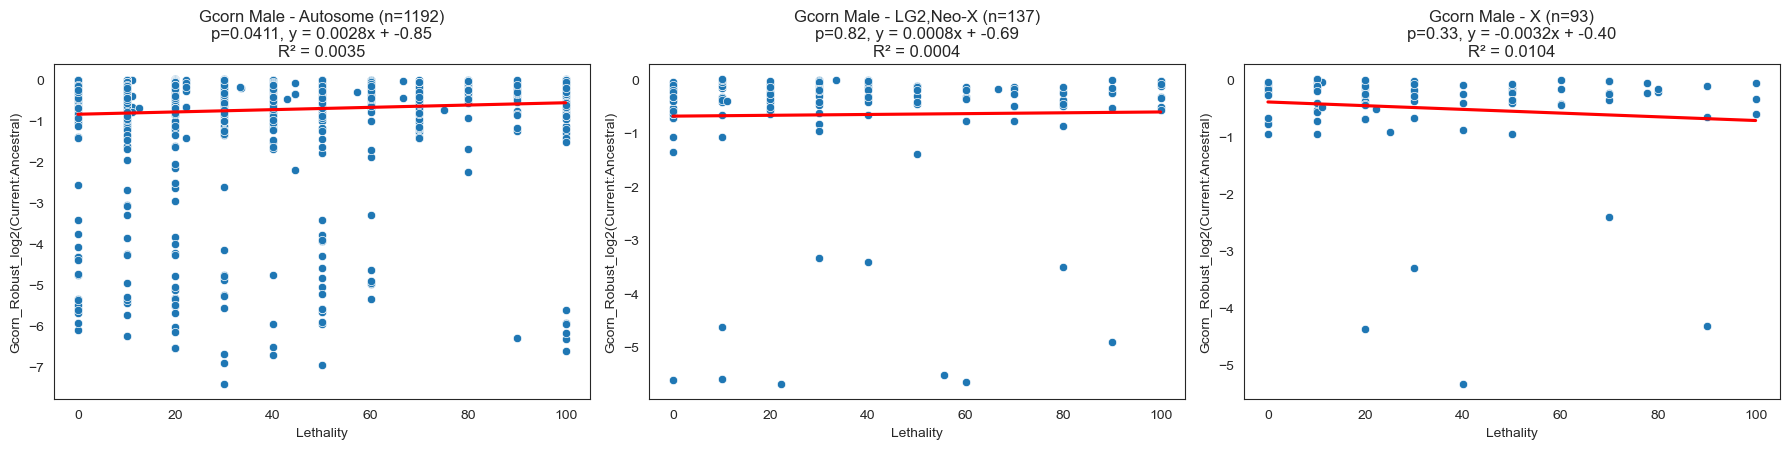

Gcorn | Female | Autosome: n=1207, slope=0.0021, intercept=-0.8234, R²=0.0021, p=1.084e-01, SE=0.0013
Gcorn | Female | LG2,Neo-X: n=154, slope=-0.0010, intercept=-0.6470, R²=0.0006, p=7.566e-01, SE=0.0033
Gcorn | Female | X: n=100, slope=-0.0025, intercept=-0.5597, R²=0.0038, p=5.444e-01, SE=0.0042


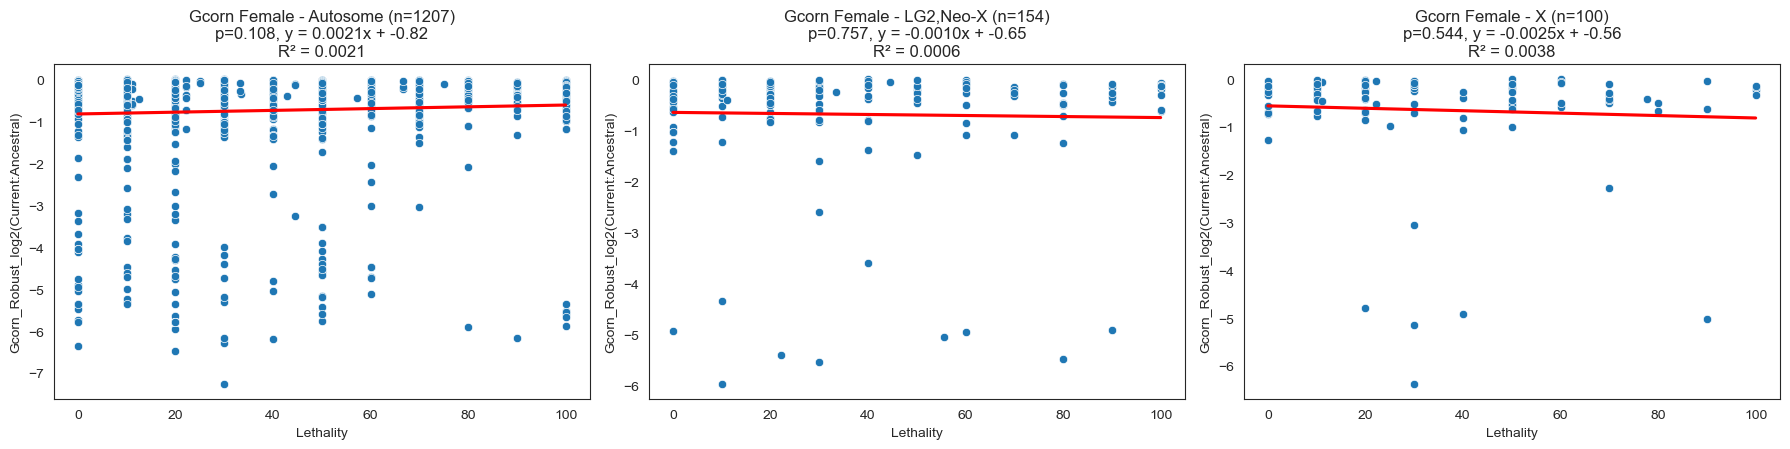

In [7]:
female_df = pd.read_csv('ToD_Fig5_Female_data.csv')
male_df = pd.read_csv('ToD_Fig5_Male_data.csv')

species_list = ['Tcas', 'Tcon', 'Tfrem', 'Tbrev', 'Gcorn']
species_cols = [
    'Tcas_Robust_log2(Current:Ancestral)',
    'Tcon_Robust_log2(Current:Ancestral)',
    'Tfrem_Robust_log2(Current:Ancestral)',
    'Tbrev_Robust_log2(Current:Ancestral)',
    'Gcorn_Robust_log2(Current:Ancestral)'
]

def plot_by_chrom(data, sex_label, species_col, output_filename):
    species = species_col.split('_')[0]
    unique_chroms = data['chrom_name'].unique()
    selected_chroms = unique_chroms[:3]
    plt.figure(figsize=(18, 5))
    for i, chrom in enumerate(selected_chroms, 1):
        chrom_data = data[data['chrom_name'] == chrom]
        # Keep only negative log2 values
        chrom_data = chrom_data[
            chrom_data[species_col] < 0
        ]
        n_genes = len(chrom_data)
        x = chrom_data['dali11']
        y = chrom_data[species_col]
        
        # Perform regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        print(
            f"{species} | {sex_label} | {chrom}: "
            f"n={n_genes}, "
            f"slope={slope:.4f}, "
            f"intercept={intercept:.4f}, "
            f"R²={r_value**2:.4f}, "
            f"p={p_value:.3e}, "
            f"SE={std_err:.4f}")
        # Plot
        plt.subplot(1, 3, i)
        sns.scatterplot(x=x, y=y)
        sns.regplot(x=x, y=y, scatter=False, color='red',ci=None)
        plt.title(f'{species} {sex_label} - {chrom} (n={n_genes})\np={p_value:.3g}, y = {slope:.4f}x + {intercept:.2f}\nR² = {r_value**2:.4f}')
        plt.xlabel('Lethality')
        plt.ylabel(species_col)
        #plt.ylim(0, 2)
        plt.xlim(-5, 105)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Save to file
    plt.savefig(output_filename, dpi=300)
    plt.show()
#    print(f"Plot was saved as {output_filename}")
from pathlib import Path

output_dir = Path('Figure_5')
output_dir.mkdir(parents=True, exist_ok=True)
   
for species_col in species_cols:
    species = species_col.split('_')[0]
    plot_by_chrom(male_df,'Male',species_col,output_dir / f'{species}_male_neglog2_linreg.png')
    plot_by_chrom(female_df,'Female',species_col,output_dir / f'{species}_female_neglog2_linreg.png')

In [3]:
import sys
import importlib.metadata as metadata

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "statsmodels",
    "seaborn",
    "matplotlib"
]

print(f"Python: {sys.version.split()[0]}")

for package in packages:
    print(f"{package}: {metadata.version(package)}")

Python: 3.12.2
numpy: 1.26.4
pandas: 2.2.2
scikit-learn: 1.4.2
scipy: 1.13.1
statsmodels: 0.14.2
seaborn: 0.13.2
matplotlib: 3.8.4
